In [ ]:
from sklearn.neighbors import kneighbors_graph
import numpy as np

In [ ]:
def get_neighbor(idx, connectivity, points):
    neibor_idx = np.arange(len(points))[connectivity[idx]]
    return neibor_idx

In [ ]:
X = [[0], [3], [1.5], [-0.5]]
X = np.array(X)
# X=np.random.random((200,60))

A = kneighbors_graph(X, 2, mode="connectivity", include_self=False).toarray().astype(bool)
get_neighbor(2, A, X)

array([0, 1])

In [ ]:
x = np.array([[2, 0, 1], [3, 1, 1], [4, 2, 2], [5, 3, 2]], dtype="f8")
x = x - np.mean(x, axis=0)
print(x)

[[-1.5 -1.5 -0.5]
 [-0.5 -0.5 -0.5]
 [ 0.5  0.5  0.5]
 [ 1.5  1.5  0.5]]


In [ ]:
u, s, vt = np.linalg.svd(x)
# 因为s的最后一个特征值接近0，所以这里取两个特征值，
# 因此取vt的前两列，那么x被降维成：
x_ = x @ (vt[:2].T)
print(x_)

[[-2.17682365 -0.10695241]
 [-0.81790909  0.28464843]
 [ 0.81790909 -0.28464843]
 [ 2.17682365  0.10695241]]


In [5]:
print(vt.T)

[[ 6.79457280e-01  1.95800420e-01  7.07106781e-01]
 [ 6.79457280e-01  1.95800420e-01 -7.07106781e-01]
 [ 2.76903610e-01 -9.60897700e-01 -8.74247957e-19]]


In [ ]:
# 重构
x_ @ vt[:2]

array([[-1.5, -1.5, -0.5],
       [-0.5, -0.5, -0.5],
       [ 0.5,  0.5,  0.5],
       [ 1.5,  1.5,  0.5]])

In [ ]:
x = np.array([[1.0, 1.0, 0.0], [1.0, 0.9, 0.0], [1.0, 1.1, 0.0]], dtype="f8")
X = x.T @ x
eigvalues, eigvectors = np.linalg.eigh(X)
print(eigvalues)
print(eigvectors)

[0.         0.00998333 6.01001667]
[[ 0.         -0.70828431  0.70592729]
 [ 0.          0.70592729  0.70828431]
 [ 1.          0.          0.        ]]


In [ ]:
x = np.array([[1, 2, 3], [2, 3, 4]], dtype="f8")
norm_x = np.linalg.norm(x, axis=1, keepdims=True)
print(x / norm_x)
print(np.linalg.norm(x / norm_x, axis=1, keepdims=True))

[[0.26726124 0.53452248 0.80178373]
 [0.37139068 0.55708601 0.74278135]]
[[1.]
 [1.]]


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
def normalization(vec):
    std = np.linalg.norm(vec, axis=1, keepdims=True)
    vec = vec / std
    return vec


def get_domain_vector(vectors, include=0.9):
    vectors = normalization(vectors)
    U, S, VT = np.linalg.svd(vectors, full_matrices=False)
    energy = S**2
    total_energy = np.sum(energy)
    k = np.argmax(np.cumsum(energy) > include * total_energy) + 1
    main_vec = VT[:k, :]

    mean_d = np.mean(vectors, axis=0)
    print(U)
    print(S)
    print(VT)


def get_main(vectors, include=0.9):
    vectors = normalization(vectors)
    cov = vectors.T @ vectors
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    sort_idx = np.argsort(eigenvalues)[::-1]
    sort_eigenvalues = eigenvalues[sort_idx]
    sort_eigenvectors = eigenvectors[:, sort_idx]

    total_energy = np.sum(sort_eigenvalues)
    k = np.argmax(np.cumsum(sort_eigenvalues) > include * total_energy) + 1
    main_vec = sort_eigenvectors[:, :k]

    print(main_vec)
    print(sort_eigenvalues[:k])


x = np.array([[1, 1], [3, 0], [0, 1], [2, 2]], dtype="f8")
# x=np.array([[2,0,0],[3,1,1],[4,2,2],[5,3,2]],dtype="f8")
get_main(x)

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
[3. 1.]


In [ ]:
prob = np.array([0.1, 0.2, 0.5, 0.2])
prob = prob / np.sum(prob)
cum_prob = np.cumsum(prob)
cum_prob = np.insert(cum_prob, 0, 0.0)
rand = 0.9

print(cum_prob)
print(rand < cum_prob)
print(np.argmax(rand < cum_prob) - 1)

[0.  0.1 0.3 0.8 1. ]
[False False False False  True]
3


In [ ]:
x = np.array([1, 2, 3])
mask = 2
x[~mask]

np.int64(1)

In [ ]:
import numpy as np

x = np.array([[1, 0], [0, 1], [0, 0]])
cov = x.T @ x
eigvals, eigvecs = np.linalg.eigh(cov)
print(eigvals)
print(eigvecs)

[1. 1.]
[[1. 0.]
 [0. 1.]]


In [ ]:
import numpy as np

x = np.array([[1, 0], [1, 1], [1, 2], [0, 5]])
# x=x/np.linalg.norm(x,axis=1,keepdims=True)
print(x)
w = np.array([2, 1, 1, 1])
w = w / np.sum(w)
x_mean = w @ x
x_center = x - x_mean
print(x_center)
x_C = x_center.T @ np.diag(w) @ x_center
print(x_C)
eigenvalues, eigenvectors = np.linalg.eigh(x_C)
print(eigenvalues)
print(eigenvectors)

[[1 0]
 [1 1]
 [1 2]
 [0 5]]
[[ 0.2 -1.6]
 [ 0.2 -0.6]
 [ 0.2  0.4]
 [-0.8  3.4]]
[[ 0.16 -0.68]
 [-0.68  3.44]]
[0.02461272 3.57538728]
[[-0.98075025 -0.19526634]
 [-0.19526634  0.98075025]]


In [ ]:
x = np.array(
    [
        [1, 0],
        [1, 1],
        [2, 2],
        [0, 5],
    ]
)
x_normal = x / np.linalg.norm(x, axis=1, keepdims=True)
w = np.array([2, 1, 1, 1])
w = w / np.sum(w)

# x_mean=w@x
# x_center=x-x_mean
# x_normal=x_center/np.linalg.norm(x_center,axis=1,keepdims=True)
# print(x_normal)
x_scale = np.diag(np.sqrt(w)) @ x_normal
cov = x_scale.T @ x_scale
eigenvalues, eigenvectors = np.linalg.eigh(cov)
print(eigenvalues)
print(eigenvectors)

proj = np.sum(x_scale @ eigenvectors, axis=0)
# print(proj)
sign = np.sign(proj)
sign[sign == 0.0] = 1.0
# print(sign)
eigenvectors_modify = eigenvectors * sign
print(eigenvectors_modify)

[0.2763932 0.7236068]
[[ 0.52573111 -0.85065081]
 [-0.85065081 -0.52573111]]
[[-0.52573111  0.85065081]
 [ 0.85065081  0.52573111]]


In [ ]:
x = np.array(
    [
        [
            1,
            0,
        ],
        [
            2,
            0,
        ],
        [
            0,
            1,
        ],
        [
            0,
            5,
        ],
    ]
)
w = np.array([2, 1, 1, 1])
w = w / np.sum(w)

x = x / np.linalg.norm(x, axis=1, keepdims=True)
print(x)
cov = x.T @ x
eigenvalues, eigenvectors = np.linalg.eigh(cov)
print(eigenvalues)
print(eigenvectors)


proj = np.sum(x @ eigenvectors, axis=0)
print(proj)
sign = np.sign(proj)
sign[sign == 0.0] = 1.0
print(sign)
eigenvectors_modify = eigenvectors * sign
print(eigenvectors_modify)

[[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
[2. 2.]
[[1. 0.]
 [0. 1.]]
[2. 2.]
[1. 1.]
[[1. 0.]
 [0. 1.]]


In [ ]:
import numpy as np

xb = np.array([[1, 0, 0], [0, 2, 0], [1, 1, 0]])
xb = xb / np.linalg.norm(xb, axis=1, keepdims=True)
xw = np.array([[-1, -1, 0]])
xw = xw / np.linalg.norm(xw, axis=1, keepdims=True)

xb_eigvalue, xb_eigvector = np.linalg.eigh(xb.T @ xb)
xw_eigvalue, xw_eigvector = np.linalg.eigh(xw.T @ xw)

print(xb_eigvalue)
print(xb_eigvector)
print()
print(xw_eigvalue)
print(xw_eigvector)
print()

xi_b = xb_eigvector[:, 1:] @ (np.sqrt(np.diag(xb_eigvalue[1:])) @ np.random.random(size=(2, 1)))
proj_xi_w = xw_eigvector[:, 2:] @ (xw_eigvector[:, 2:].T @ xi_b)
print(xi_b)
print(proj_xi_w)

[0. 1. 2.]
[[ 0.         -0.70710678  0.70710678]
 [ 0.          0.70710678  0.70710678]
 [ 1.          0.          0.        ]]

[0. 0. 1.]
[[-0.70710678  0.          0.70710678]
 [ 0.70710678  0.          0.70710678]
 [ 0.          1.          0.        ]]

[[0.48713407]
 [1.22964193]
 [0.        ]]
[[0.858388]
 [0.858388]
 [0.      ]]


In [ ]:
x = np.array([1, 2, 4, 3, 9, 8, 6])
ind = np.argsort(x)[::-1]
print(x[ind])

[9 8 6 4 3 2 1]


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -1.7320508e+00 3.90e+00 8.01e-02   0.0 0.00e+00    -  0.00e+00 0.00e+00 

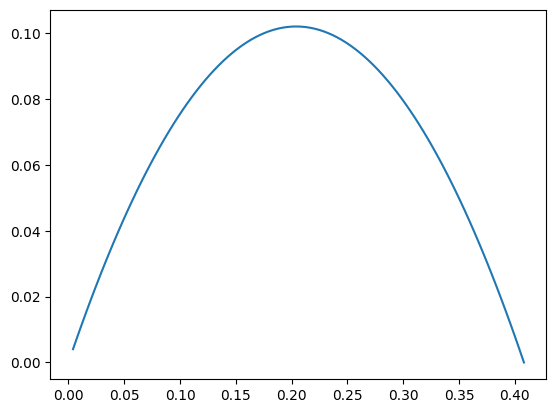

In [ ]:
import casadi as ca
from NumOpt import Opti
import numpy as np

x_hst = []
y_hst = []
vx_hst = []
vy_hst = []


def f(states, dt):
    vx0 = states[0, 0]
    vy0 = states[1, 0]
    x0 = states[2, 0]
    y0 = states[3, 0]

    vx1 = vx0
    vy1 = vy0 - 9.8 * dt
    x1 = x0 + (vx0 + vx1) / 2.0 * dt
    y1 = y0 + (vy0 + vy1) / 2.0 * dt
    new_states = ca.vertcat(vx1, vy1, x1, y1)
    return new_states


def gen_cafunc():
    # x0=ca.GenSX_sym("x")
    # y0=ca.GenSX_sym("y")
    # vx0=ca.GenSX_sym("vx")
    # vy0=ca.GenSX_sym("vy")
    states = ca.GenSX_sym("states", 4, 1)
    dt0 = ca.GenSX_sym("dt")
    new_states = f(states, dt0)
    F = ca.Function("F", [states, dt0], [new_states])
    return F


F = gen_cafunc()
F_fold = F.fold(100)
F_cum = F.mapaccum(100)


opti = Opti()
theta = opti.variable(init_guess=30.0, lower_bound=0.0, upper_bound=90.0)
dt = opti.variable(init_guess=0.01, lower_bound=0.0)

x0 = 0.0
y0 = 0.0
V = 2.0
vx0 = V * ca.cos(theta / 180.0 * ca.pi)
vy0 = V * ca.sin(theta / 180.0 * ca.pi)
states0 = ca.vertcat(vx0, vy0, x0, y0)

# statesf=F_fold(states0,dt)
statesf = F_cum(states0, dt)
# print(statesf)
opti.subject_to([statesf[3, -1] == 0.0])
opti.maximize(statesf[2, -1])
opti.solver()
sol = opti.solve()
print(sol(theta))
# print(sol(dt))
# print(sol(statesf))

import matplotlib.pyplot as plt

fig = plt.figure(0)
ax = fig.add_subplot(111)
ax.plot(sol(statesf)[2, :], sol(statesf)[3, :])
plt.show()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -4.0373323e+00 9.31e-01 1.48e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

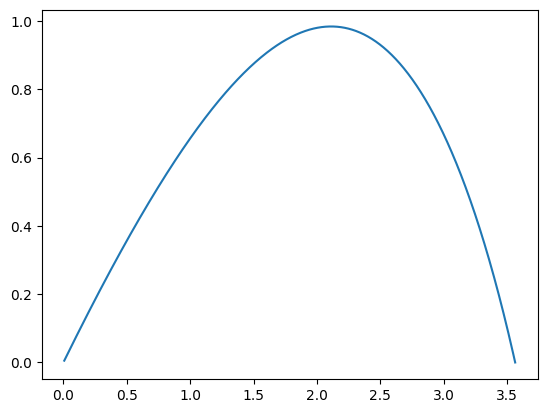

In [ ]:
import casadi as ca
from NumOpt import Opti
import numpy as np

x_hst = []
y_hst = []
vx_hst = []
vy_hst = []


def ode(states, cd, dt):
    vx0 = states[0, 0]
    vy0 = states[1, 0]
    x0 = states[2, 0]
    y0 = states[3, 0]

    v0 = ca.sqrt(vx0**2 + vy0**2)
    sin_theta = vy0 / v0
    cos_theta = vx0 / v0

    drag = 0.5 * 1.225 * v0**2 * cd
    dragx = drag * cos_theta
    dragy = drag * sin_theta

    vx1 = vx0 - dragx * dt
    vy1 = vy0 - (9.8 + dragy) * dt
    x1 = x0 + (vx0 + vx1) / 2.0 * dt
    y1 = y0 + (vy0 + vy1) / 2.0 * dt
    new_states = ca.vertcat(vx1, vy1, x1, y1)
    return new_states


def gen_cafunc():
    # x0=ca.GenSX_sym("x")
    # y0=ca.GenSX_sym("y")
    # vx0=ca.GenSX_sym("vx")
    # vy0=ca.GenSX_sym("vy")
    states = ca.GenSX_sym("states", 4, 1)
    dt = ca.GenSX_sym("dt")
    cd = ca.GenSX_sym("cd")
    new_states = ode(states, cd, dt)
    F = ca.Function("F", [states, cd, dt], [new_states])
    return F


N = 1000
F = gen_cafunc()
F_fold = F.fold(N)
F_cum = F.mapaccum(N)

opti = Opti()
theta = opti.variable(init_guess=30.0, lower_bound=0.0, upper_bound=90.0)
tf = opti.variable(init_guess=1.0, lower_bound=0.0)
dt = tf / (N - 1)

x0 = 0.0
y0 = 0.0
V = 10.0
cd = 0.5
vx0 = V * np.cos(theta / 180.0 * np.pi)
vy0 = V * np.sin(theta / 180.0 * np.pi)
states0 = ca.vertcat(vx0, vy0, x0, y0)

# statesf=F_fold(states0,dt)
statesf = F_cum(states0, cd, dt)
# print(statesf)
opti.subject_to(
    [
        statesf[3, -1] == 0.0,
    ]
)
opti.maximize(statesf[2, -1])
opti.solver()
try:
    sol = opti.solve()
except:
    sol = opti.debug.value
print(sol(theta))
print(sol(dt))
print(sol(statesf)[:, -1])
print(sol(vx0), sol(vy0))
print(sol(statesf)[:, 0])

import matplotlib.pyplot as plt

fig = plt.figure(0)
ax = fig.add_subplot(111)
ax.plot(sol(statesf)[2, :], sol(statesf)[3, :])
plt.show()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -4.0373323e+00 9.31e-01 1.48e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

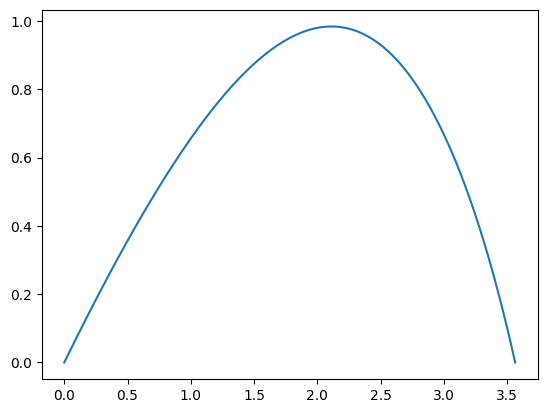

In [3]:
import casadi as ca
from NumOpt import Opti
import numpy as np

opti = Opti()
theta = opti.variable(init_guess=30.0, lower_bound=0.0, upper_bound=90.0)
tf = opti.variable(init_guess=1.0, lower_bound=0.0)
N = 1000
dt = tf / (N - 1)

vx_hst = []
vy_hst = []
x_hst = []
y_hst = []

x = 0.0
y = 0.0
V = 10.0
vx = V * np.cos(theta / 180.0 * np.pi)
vy = V * np.sin(theta / 180.0 * np.pi)
cd = 0.5

vx_hst.append(vx)
vy_hst.append(vy)
x_hst.append(x)
y_hst.append(y)

for i in range(N):
    v = ca.sqrt(vx**2 + vy**2)
    cos_theta = vx / v
    sin_theta = vy / v
    drag = 0.5 * 1.225 * v**2 * cd
    dragx = drag * cos_theta
    dragy = drag * sin_theta

    vx1 = vx - dragx * dt
    vy1 = vy - 9.8 * dt - dragy * dt
    x1 = x + (vx + vx1) / 2.0 * dt
    y1 = y + (vy + vy1) / 2.0 * dt

    vx_hst.append(vx1)
    vy_hst.append(vy1)
    x_hst.append(x1)
    y_hst.append(y1)

    vx = vx1
    vy = vy1
    x = x1
    y = y1

vx_hst = ca.hcat(vx_hst)
vy_hst = ca.hcat(vy_hst)
x_hst = ca.hcat(x_hst)
y_hst = ca.hcat(y_hst)

opti.subject_to([y_hst[0, -1] == 0.0])

opti.maximize(x_hst[0, -1])
opti.solver()
sol = opti.solve()
print(sol(theta))

import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(sol(x_hst), sol(y_hst))
plt.show()

In [ ]:
import numpy as np
import casadi as ca
import jax.numpy as jnp
import jax

In [ ]:
def func(x):
    ret = x * np.sin(x) + x
    return ret


N = int(1e7)
for i in range(N):
    ret = func(i)
print(ret)

19906644.486696616


In [ ]:
def gen_func():
    def _fun(x):
        ret = x * ca.sin(x) + x
        return ret

    x = ca.GenSX_sym("x")
    ret = _fun(x)
    func = ca.Function("func", [x], [ret])
    return func


func = gen_func()
N = int(1e7)
for i in range(N):
    ret = func(i)
print(ret)

1.99066e+07


In [ ]:
@jax.jit()
def func(x):
    ret = x * jnp.sin(x) + x
    return ret


N = int(1e7)
for i in range(N):
    ret = func(i)
print(ret)

1.9906644e+07


In [ ]:
def func(N):
    def _func(i, x):
        ret = i * jnp.sin(i) + i
        return ret

    return jax.lax.fori_loop(0, N, _func, 0)


N = int(1e7)
print(func(N))

1.9906644e+07


In [ ]:
def f(x, c=5):
    return x**3 - 2 * x - c


from scipy.optimize import elementwise, brent, brenth

res_bracket = elementwise.bracket_root(f, 1, factor=1.2)
res_bracket.success
print(res_bracket.bracket)

# xmin, fval, iter, funcalls  = brent(f,brack=res_bracket.bracket,full_output=True)
# print(xmin,fval)

root = brenth(f, a=res_bracket.bracket[0], b=res_bracket.bracket[1])
print(root)
print(f(root))

(np.float64(2.0), np.float64(2.2))
2.0945514815420427
-3.169020601490047e-12


In [ ]:
import csdl_alpha as csdl
from csdl_alpha.experimental import PySimulator
import modopt as mo
import numpy as np

rec = csdl.Recorder()
rec.start()

cg = np.array([5.75, 0.0, -0.25])
G = 5.5e3 * 9.8

throttle = csdl.Variable(value=np.ones(6) * G / 6.0)
throttle_max = csdl.Variable(value=G / 6.0)

rotor_x = csdl.Variable(value=np.array([3.2, 5.9, 10.06, 3.2, 5.9, 10.06]))
rotor_y = csdl.Variable(value=np.array([2.95, 6.5, 2.0, -2.95, -6.5, -2.0]))

con1 = rotor_y[:3] + rotor_y[3:]
con2 = rotor_y[0] - 2.95
con3 = rotor_y[1] - 6.5
con4 = rotor_y[2] - 2.0

con5 = rotor_x[:3] - rotor_x[3:]
con6 = rotor_x[0]
con7 = rotor_x[1] - 5.9
con8 = rotor_x[2]

con9 = My = csdl.vdot(rotor_x - cg[0], throttle)
con10 = Mx = csdl.vdot(rotor_y, throttle)

con11 = totot_T = csdl.sum(throttle)
con12 = throttle_max - throttle

idx = 1
con13 = throttle[idx]

throttle.set_as_design_variable(lower=0.0)
throttle_max.set_as_design_variable(lower=0.0)
rotor_x.set_as_design_variable()
rotor_y.set_as_design_variable()

con1.set_as_constraint(equals=0.0)
con2.set_as_constraint(equals=0.0)
con3.set_as_constraint(equals=0.0)
con4.set_as_constraint(equals=0.0)
con5.set_as_constraint(equals=0.0)
con6.set_as_constraint(lower=3.0, upper=3.5)
con7.set_as_constraint(equals=0.0)
con8.set_as_constraint(lower=10.0, upper=11.0)
con9.set_as_constraint(equals=0.0)
con10.set_as_constraint(equals=0.0)
con11.set_as_constraint(equals=G)
con12.set_as_constraint(lower=0.0)
con13.set_as_constraint(equals=0.0)

throttle_max.set_as_objective()

rec.stop()


sim = PySimulator(recorder=rec)
prob = mo.CSDLAlphaProblem(problem_name="propeller", simulator=sim)

# optimizer=mo.IPOPT(problem=prob,solver_options={"max_iter":100,"tol":1e-6})
optimizer = mo.SLSQP(problem=prob, solver_options={"maxiter": 100, "ftol": 1e-6})
sol = optimizer.solve()
optimizer.print_results()

print(throttle.value)
print(throttle.value / G * 6)

In [ ]:
import csdl_alpha as csdl


class UDP(csdl.CustomExplicitOperation):
    def __init__(self):
        super().__init__()

    def evaluate(self, x):
        self.declare_input("x", variable=x)
        z = self.create_output("z", shape=(1,))

        self.declare_derivative_parameters(of="z", wrt="x", method="fd")

        return z

    def compute(self, inputs, outputs):
        x = inputs["x"]
        outputs["z"] = x**2 - 10

    # def compute_derivatives(self, inputs, outputs, derivatives):
    #     # x=inputs["x"]
    #     # derivatives["z","x"]=2*x
    #     pass


rec = csdl.Recorder(inline=True)
rec.start()

x = csdl.ImplicitVariable(value=5)

udp = UDP()
z = udp.evaluate(x)
# z=x**2-1

solver = csdl.nonlinear_solvers.BracketedSearch()
solver.add_state(x, z, bracket=(0, 2))

solver.run()

rec.stop()


print(x.value)
print(z.value)

KeyboardInterrupt: 

In [ ]:
import casadi as ca
import jax.numpy as jnp


class Bspline:
    def __init__(self, cpts: np.ndarray, degree=3):
        self.cpts = cpts
        self.degree = degree
        self.segments = self.cpts.shape[0] - self.degree
        if self.segments < 1:
            raise ValueError("the contrl points number must be > degree")
        self.knots = self.quasi_uniform_knots()

    def quasi_uniform_knots(self):
        middle = np.linspace(0, 1, self.segments + 1)
        start = np.zeros(self.degree, dtype="f8")
        end = np.ones(self.degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    @staticmethod
    def deBoor(u, i, k, knots):
        if k == 0:
            flag = ca.logic_and(u >= knots[i], u < knots[i + 1])
            return ca.if_else(flag, 1.0, 0.0)
        else:
            term1 = term2 = 0.0
            delta_1 = knots[i + k] - knots[i]
            if delta_1 != 0.0:
                term1 = (u - knots[i]) / (delta_1) * Bspline.deBoor(u, i, k - 1, knots)

            delta_2 = knots[i + k + 1] - knots[i + 1]
            if delta_2 != 0.0:
                term2 = (knots[i + k + 1] - u) / delta_2 * Bspline.deBoor(u, i + 1, k - 1, knots)
            return term1 + term2


cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [1.0, 0.0]])
sp = Bspline(cpts=cpts)
sp.deBoor(u=np.array([0.0, 0.5, 1.0]), i=1, k=3, knots=sp.knots)

DM([0, 0.375, 0])

[0.6625 0.6375]
0.637499999907903
[[ 1.575  0.525]
 [ 1.896 -0.048]]
[[ 2.7  -5.1 ]
 [ 3.72 -6.36]]


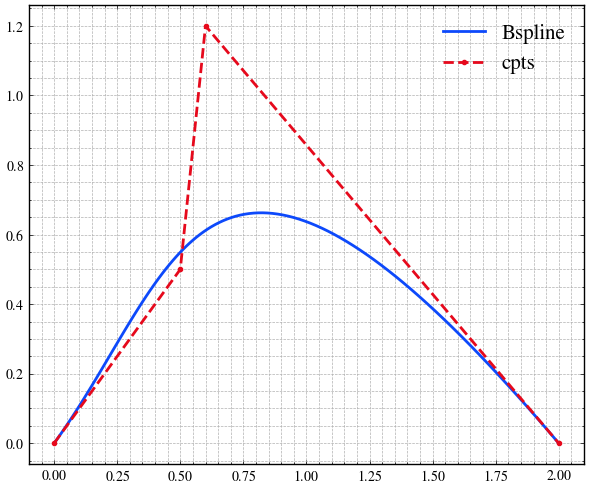

In [ ]:
from scipy.interpolate import BSpline, interp1d
import matplotlib.pyplot as plt
import scienceplots


class Bspline:
    def __init__(self, cpts: np.ndarray, degree=3, fast_lookup=False):
        self.cpts = cpts
        self.degree = degree
        self.knots = self.quasi_uniform_knots()
        self._sp = BSpline.construct_fast(t=self.knots, c=self.cpts, k=self.degree, extrapolate=True)
        self._sp_d1 = self._sp.derivative(1)
        self._sp_d2 = self._sp.derivative(2)
        if fast_lookup:
            self.look_table = self.gen_look_table()
            self.look_interp = interp1d(x=self.look_table[:, 0], y=self.look_table[:, 1], kind="cubic")

    def quasi_uniform_knots(self):
        middle = np.linspace(0, 1, self.cpts.shape[0] - self.degree + 1)
        start = np.zeros(self.degree, dtype="f8")
        end = np.ones(self.degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    def __call__(self, u):
        return self._sp(u)

    def d1(self, u):
        return self._sp_d1(u)

    def d2(self, u):
        return self._sp_d2(u)

    def gen_look_table(self):
        u = np.linspace(0, 1, 200)
        xy = self._sp(u)
        return xy

    def get_y_by_lookup(self, x):
        return self.look_interp(x)

    # def get_y_from_x(self,x):
    #     num_x=x.shape[0]

    #     u0=np.ones(num_x)*0.5
    #     ul=np.zeros(num_x)
    #     uu=np.ones(num_x)

    #     xy=BSpline()


cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
sp = Bspline(cpts=cpts, degree=3, fast_lookup=True)
u = np.linspace(0, 1, 100)
xy = sp(u)
print(sp(0.5))
print(sp.get_y_by_lookup(0.6625))
print(sp.d1([0.5, 0.6]))
print(sp.d2([0.5, 0.6]))

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))

        ax = fig.add_subplot(111)
        ax.plot(xy[:, 0], xy[:, 1], label="Bspline")
        ax.plot(cpts[:, 0], cpts[:, 1], "--o", label="cpts")

        ax.legend(fontsize=15)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        plt.show()

[1.575, 0.525]
-5.1
[0.6625, 0.6375]
[1.5, 0.387214]


func failed: .../casadi/interfaces/sundials/kinsol_interface.cpp:317: Assertion "!isnan(f_data[k])" failed:
Nonzero 0 is not-a-number



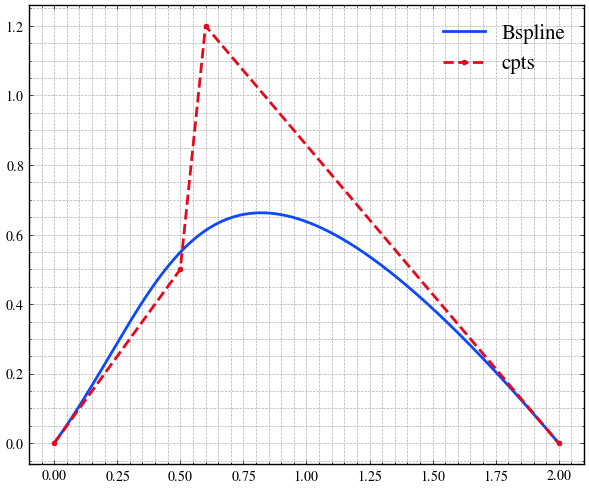

In [ ]:
import casadi as ca
from scipy.interpolate import BSpline
import numpy as np
import matplotlib.pyplot as plt
import scienceplots


class BsplineCasadi(ca.Callback):
    def __init__(self, name, cpts: np.ndarray, degree=3, extrapolate=False, opts={"enable_fd": False}):
        ca.Callback.__init__(self)
        self.construct(name, opts)
        self.cpts = cpts
        self.degree = degree
        self.knots = self.quasi_uniform_knots()
        self._sp = BSpline.construct_fast(t=self.knots, c=self.cpts, k=self.degree, extrapolate=extrapolate)
        self._sp_d1 = self._sp.derivative(1)
        self._sp_d2 = self._sp.derivative(2)

        self.get_xy_from_x = self.gen_get_y_from_x()

    def quasi_uniform_knots(self):
        middle = np.linspace(0, 1, self.cpts.shape[0] - self.degree + 1)
        start = np.zeros(self.degree, dtype="f8")
        end = np.ones(self.degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    def get_n_in(self):
        return 1

    def get_sparsity_in(self, i):
        return ca.Sparsity.dense(1, 1)

    def get_n_out(self):
        return 1

    def get_sparsity_out(self, i):
        return ca.Sparsity.dense(2, 1)

    def eval(self, args):
        u = args[0]
        u = u.toarray().ravel()
        xy = self._sp(u).reshape((-1, 1))
        return [xy]

    def has_jacobian(self):
        return True

    def get_jacobian(self, name, inames, onames, opts):
        class JacFun(ca.Callback):
            def __init__(self_jac, opts={"enable_fd": False}):
                ca.Callback.__init__(self_jac)
                self_jac.construct(name, opts)

            def get_n_in(self_jac):
                return 2

            def get_n_out(self_jac):
                return 1

            def get_sparsity_in(self_jac, i):
                if i == 0:
                    return ca.Sparsity.dense(1, 1)
                elif i == 1:
                    return ca.Sparsity.dense(2, 1)

            def get_sparsity_out(self_jac, i):
                return ca.Sparsity.dense(2, 1)

            def eval(self_jac, args):
                u = args[0]
                u = u.toarray().ravel()
                jac = self._sp_d1(u).reshape((-1, 1))
                return [jac]

            def has_jacobian(self_jac):
                return True

            def get_jacobian(self_jac, name, inames, onames, opts):
                class HessFun(ca.Callback):
                    def __init__(self_hess, opts={}):
                        ca.Callback.__init__(self_hess)
                        self_hess.construct(name, opts)

                    def get_n_in(self_hess):
                        return 3

                    def get_n_out(self_hess):
                        return 2

                    def get_sparsity_in(self_hess, i):
                        if i == 0:
                            return ca.Sparsity.dense(1, 1)
                        elif i == 1:
                            return ca.Sparsity.dense(2, 1)
                        elif i == 2:
                            return ca.Sparsity.dense(2, 1)

                    def get_sparsity_out(self_hess, i):
                        if i == 0:
                            return ca.Sparsity.dense(2, 1)
                        elif i == 1:
                            return ca.Sparsity.dense(2, 2)

                    def eval(self_hess, args):
                        u = args[0]
                        u = u.toarray().ravel()
                        hess_u = self._sp_d2(u).reshape((-1, 1))
                        hess_xy = ca.GenDM_zeros(2, 2)
                        return [hess_u, hess_xy]

                self_jac.jac_callback = HessFun()
                return self_jac.jac_callback

        self.jac_callback = JacFun()
        return self.jac_callback

    def gen_get_y_from_x(self):
        x = ca.SX.sym("x")
        u_star = self.__get_y_from_x()(0.5, x)
        xy_star = self(u_star)

        func = ca.Function("get_y_from_x", [x], [xy_star])
        return func

    def __get_y_from_x(self):
        u = ca.SX.sym("u")
        x = ca.SX.sym("x")
        xy = self(u)
        F1 = xy[0, 0] - x

        g = ca.Function("g", [u, x], [F1])
        sol = ca.rootfinder("G", "kinsol", g)
        return sol


cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
sp = BsplineCasadi("sp", cpts=cpts, degree=3)
# print(sp(0.5))

u = np.linspace(0, 1, 1000)
dumpy_x = ca.SX.sym("x")
sp_func = ca.Function("sp_func", [dumpy_x], [sp(dumpy_x)])
sp_func_jac = ca.Function("sp_func", [dumpy_x], [ca.jacobian(sp(dumpy_x), dumpy_x)])
sp_func_hess = ca.Function("sp_func", [dumpy_x], [ca.hessian(sp(dumpy_x)[1, 0], dumpy_x)[0]])

print(sp_func_jac(0.5))
print(sp_func_hess(0.5))
sp_func_mpi = sp_func.map(u.shape[0])

xy_list = sp_func_mpi(u).T


# from NumOpt import Opti
# opti=Opti()
# u=opti.variable(init_guess=0.5,lower_bound=0.0,upper_bound=1.0)
# xy=sp(u).T
# opti.subject_to([
#     xy[0,0]==0.6625
# ])
# opti.ipopt_solver()
# sol=opti.solve()
# print(sol(xy))

print(sp.get_xy_from_x(0.6625))
print(sp.get_xy_from_x(1.5))

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))

        ax = fig.add_subplot(111)
        ax.plot(xy_list[:, 0], xy_list[:, 1], label="Bspline")
        ax.plot(cpts[:, 0], cpts[:, 1], "--o", label="cpts")

        ax.legend(fontsize=15)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        plt.show()

In [ ]:
import casadi as ca

x = ca.SX.sym("x", 1, 1)
y1 = x
y2 = 2 * x**2
# y=ca.veccat(y1,y2)
y = ca.veccat(y1, y2)
func = ca.Function("func", [x], [y])
func_jac = ca.Function("func_jac", [x], [ca.jacobian(func(x), x)])
func_hess = ca.Function("func_hess", [x], [ca.hessian(func(x)[1, 0], x)[0]])

func(2).shape, func_jac(2).shape, func_hess(2)

((2, 1), (2, 1), DM(4))

In [ ]:
import casadi as ca
import aerosandbox.numpy as anp

anp.prod
x = ca.SX.sym("x", 2, 1)
p = ca.SX.sym("p", 1, 1)

F1 = ca.sum(x) - p
F2 = x[0, 0] * x[1, 0] - p
F = ca.vertcat(F1, F2)
g = ca.Function("g", [x, p], [F])

G = ca.rootfinder("G", "kinsol", g)
sol = G([0.5, 2.0], 4)
print(sol)

[2, 2]


In [ ]:
import casadi as ca

# 1. 定义 F(z,p) = 0
z = ca.SX.sym("z")  # 未知量，必须放第一个输入
p = ca.SX.sym("p")  # 参数，放第二个输入，可以是向量
F = z**2 - p  # 等式方程，写成 残差 = 0 的形式

F_func = ca.Function("F", [z, p], [F])

# 2. 造求解器
rf = ca.rootfinder("rf", "kinsol", F_func)

# 3. 求解，给 初值z0, 参数p
z_sol = rf(1.0, 16)  # 解 z^2=2，初值1 -> 1.4142...
print(z_sol)

-4


In [ ]:
import casadi as ca

x = ca.SX.sym("x")
thresholds = [0.5, 2.0]
idx = ca.sum(x > thresholds)

f0 = ca.DM.ones(1, 1)
f1 = -x + 1
f2 = 2 * x - 2

cond = ca.conditional(idx, [f0, f1], f2)
func_cond = ca.Function("func_cond", [x], [cond])

func_cond(3)

DM(4)

In [ ]:
import casadi as ca
import jax
import jax.numpy as jnp


def gen_f():
    x = ca.SX.sym("x")
    y = ca.sin(x)
    f = ca.Function("f", [x], [y])
    return f


f = gen_f()
N = 1000000
x = 0.74

# for _ in range(N):
#     x=f(x)
# print(x)

f_fold = gen_f().fold(N)
print(float(f_fold(x)))

dumpy_x = ca.SX.sym("dumpy_x")
f_fold_grad = ca.Function("f_fold_grad", [dumpy_x], [ca.gradient(f_fold(dumpy_x), dumpy_x)])
print(float(f_fold_grad(x)))

0.0017320397292494738
1.1302855502868415e-08


In [ ]:
import casadi as ca
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)


@jax.jit
def f(i, val):
    return jnp.sin(val)


@jax.jit
def f_mpi(x):
    return jax.lax.fori_loop(0, N, f, x)


f_mpi_grad = jax.jit(jax.grad(f_mpi))

N = 1000000
x = 0.74

# for _ in range(N):
#     x=f(_,x)
# print(x)

print(f_mpi(x=x))
print(f_mpi_grad(x))

0.001732039729249476
1.1302855502868393e-08


[0.38751725 0.4589476  0.52332931]
[[0.1397 0.1539]
 [0.6625 0.6375]
 [0.8352 0.6624]]


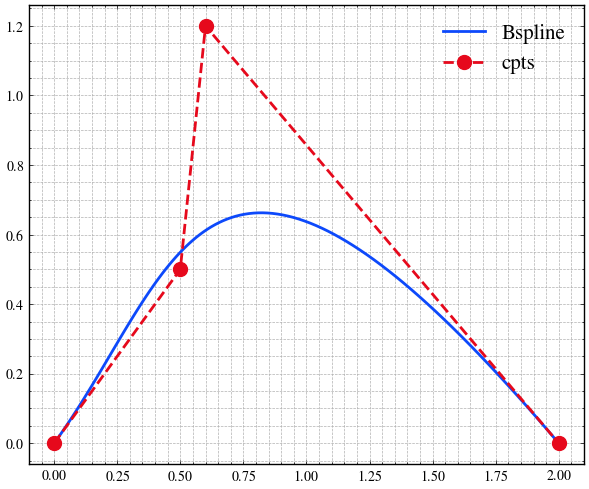

In [ ]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from NumOpt import Opti
import aerosandbox as asb


def cosspace(start: float = 0.0, stop: float = 1.0, num: int = 50):
    mean = (stop + start) / 2
    amp = (stop - start) / 2
    ones = 0 * start + 1
    spaced_array = mean + amp * np.cos(np.linspace(np.pi * ones, 0 * ones, num))

    # Fix the endpoints, which might not be exactly right due to floating-point error.
    spaced_array[0] = start
    spaced_array[-1] = stop

    return spaced_array


class BsplineCurve:
    def __init__(self, cpts: np.ndarray, degree=3):
        self.cpts = cpts
        self.degree = degree
        self.knots = self.quasi_uniform_knots(self.cpts.shape[0], self.degree)
        self.setup()

    def setup(self):
        u = ca.MX.sym("u")
        sp = ca.bspline(u, self.cpts, [self.knots], [self.degree], 1, {})
        self.spx = ca.Function("spx", [u], [sp])

    @staticmethod
    def quasi_uniform_knots(ncpts, degree):
        middle = np.linspace(0, 1, ncpts - degree + 1)
        start = np.zeros(degree, dtype="f8")
        end = np.ones(degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    def get_xy_from_u(self, u, to_numpy=True):
        xy = self.spx(u)
        if to_numpy:
            xy = xy.toarray()
        return xy

    def get_xy_from_x(self, x, to_numpy=True):
        u = ca.MX.sym("u", x.shape[0])
        xy = self.get_xy_from_u(u, False)
        residual = xy[:, 0] - x

        sol = ca.rootfinder("G", "kinsol", ca.Function("g", [u], [residual]))(np.ones((x.shape[0],)) * 0.5)
        if to_numpy:
            sol = sol.toarray().ravel()
        return sol


class BsplineAirfoil:
    def __init__(self, cptus, cptls, degree):
        self.cptus = cptus
        self.cptls = cptls
        self.degree = degree
        self._spu = BsplineCurve(cpts=self.cptus, degree=self.degree)
        self._spl = BsplineCurve(cpts=self.cptls, degree=self.degree)

    def coordinates(self, u=cosspace(0, 1, 100), to_numpy=True):
        upper_coords = self._spu.get_xy_from_u(u, to_numpy)
        lower_coords = self._spl.get_xy_from_u(u, to_numpy)
        if to_numpy:
            coords = np.vstack([upper_coords[::-1], lower_coords[1:]])
        else:
            coords = ca.vertcat(upper_coords[::-1, :], lower_coords[1:, :])
        return coords

    def upper_coordinates(self, u=cosspace(0, 1, 100), to_numpy=True):
        coords = self._spu.get_xy_from_u(u, to_numpy)
        return coords

    def lower_coordinates(self, u=cosspace(0, 1, 100), to_numpy=True):
        coords = self._spl.get_xy_from_u(u, to_numpy)
        return coords

    @staticmethod
    def fit(upper_coords, lower_coords, TE=None, ncptus=9, ncptls=9, degree=3):
        opti = Opti()

        cptus_x = np.zeros((ncptus,))
        cptus_x[1:] = cosspace(0, 1, ncptus - 1)

        cptls_x = np.zeros((ncptls,))
        cptls_x[1:] = cosspace(0, 1, ncptls - 1)

        cptus_y = opti.variable(init_guess=0.06, n_vars=ncptus - 2)
        cptls_y = opti.variable(init_guess=0.06, n_vars=ncptls - 2)

        tu = opti.variable(init_guess=0.5, n_vars=upper_coords.shape[0], lower_bound=0.0, upper_bound=1.0)
        tl = opti.variable(init_guess=0.5, n_vars=lower_coords.shape[0], lower_bound=0.0, upper_bound=1.0)

        if TE:
            cptus_y = ca.horzcat([0.0], cptus_y, [TE / 2.0])
            cptls_y = ca.horzcat([0.0], cptls_y, [-TE / 2.0])
        else:
            cptus_y = ca.horzcat([0.0], cptus_y, [upper_coords[-1, 1]])
            cptls_y = ca.horzcat([0.0], cptls_y, [lower_coords[-1, 1]])

        # cptus=ca.vertcat(cptus_x,cptus_y)
        # cptls=ca.vertcat(cptls_x,cptls_y)

        spu_x = ca.bspline(tu, cptus_x, [BsplineCurve.quasi_uniform_knots(cptus_x.shape[0])], [degree], 1, {})
        spu_y = ca.bspline(tu, cptus_y, [BsplineCurve.quasi_uniform_knots(cptus_y.shape[0])], [degree], 1, {})

        spl_x = ca.bspline(tl, cptls_x, [BsplineCurve.quasi_uniform_knots(cptls_x.shape[0])], [degree], 1, {})
        spl_y = ca.bspline(tl, cptls_y, [BsplineCurve.quasi_uniform_knots(cptls_y.shape[0])], [degree], 1, {})

        dist_u = (upper_coords[:, 0] - spu_x) ** 2 + (upper_coords[:, 1] - spu_y) ** 2
        dist_l = (lower_coords[:, 0] - spl_x) ** 2 + (lower_coords[:, 1] - spl_y) ** 2

        dist = ca.sum(dist_u) + ca.sum(dist_l)

        opti.minimize(dist)
        opti.ipopt_solver()
        sol = opti.solve()


cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
sp = BsplineCurve(cpts=cpts, degree=3)
u = np.linspace(0, 1, 100)
xy = sp.get_xy_from_u(u)
print(sp.get_xy_from_x(np.array([0.5, 0.6, 0.7])))
print(sp.get_xy_from_u([0.1, 0.5, 0.6]))


# af_init=asb.Airfoil("n63415")
# BsplineAirfoil.fit(upper_coords=af_init.upper_coordinates(),lower_coords=af_init.lower_coordinates(),TE=None,ncptus=9,ncptls=9,degree=3)


with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))

        ax = fig.add_subplot(111)
        ax.plot(xy[:, 0], xy[:, 1], label="Bspline")
        ax.plot(cpts[:, 0], cpts[:, 1], "--o", markersize=10, label="cpts")

        ax.legend(fontsize=15)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        plt.show()

In [ ]:
import casadi as ca
import numpy as np
from NumOpt import Opti


def quasi_uniform_knots(ncpts, degree):
    middle = np.linspace(0, 1, ncpts - degree + 1)
    start = np.zeros(degree, dtype="f8")
    end = np.ones(degree, dtype="f8")
    knots = np.hstack([start, middle, end])
    return knots


u = ca.MX.sym("u")
# cpts = ca.MX.sym("cpts",4,2)
cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
knots = quasi_uniform_knots(ncpts=cpts.shape[0], degree=3)

sp = ca.bspline(u, cpts.T, [knots], [3], 2, {})

sp = ca.Function("sp", [u], [sp])
# sp(ca.DM([[0.1,0.5,0.6,0.8]]),np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])).T
sp(ca.DM([[0.1, 0.5, 0.6, 0.8, 0.9]])).T

DM(
[[0.1397, 0.1539], 
 [0.6625, 0.6375], 
 [0.8352, 0.6624], 
 [1.3024, 0.5088], 
 [1.6173, 0.3051]])

In [ ]:
import casadi as ca
import numpy as np

v = ca.MX.sym("v", 5)
p0 = [-1, 0, 0.2, 1, 1.3, 2, 2.5, 3, 3.5, 4, 4.5]
p = ca.MX.sym("p", len(p0))


f = ca.Function("f", [v, p], [ca.low(v, p)])

inputs = [[0, 1, 2, 3, 4], p0]

f(*inputs)

DM([0, 0, 0, 1, 1, 2, 2, 3, 3, 3, 3])

In [ ]:
import jax
import jax.numpy as jnp
from functools import partial

jax.config.update("jax_enable_x64", True)


def quasi_uniform_knots(ncpts, degree):
    middle = jnp.linspace(0, 1, ncpts - degree + 1)
    start = jnp.zeros(degree, dtype="f8")
    end = jnp.ones(degree, dtype="f8")
    knots = jnp.hstack([start, middle, end])
    return knots


@jax.jit
def find_span(u, knots, degree, ncpts):
    s = jnp.searchsorted(knots, u, side="right") - 1
    s = jnp.clip(s, degree, ncpts - 1)
    return s


@partial(jax.jit, static_argnames=("degree",))
def de_boor(u, cpts, knots, degree):
    """
    de Boor algorithm, fully JIT-compatible.

    u : scalar
    P : (n_ctrl, dim)
    knots : (n_knots,)
    degree : int (static)

    Returns: (dim,)
    """
    p = degree

    s = find_span(u, knots, p, cpts.shape[0])

    # 取局部控制点 d[j] = P[s-p+j], j=0..p
    idx0 = s - p
    idxs = idx0 + jnp.arange(p + 1, dtype=jnp.int32)
    d = cpts[idxs, :]  # (p+1, dim)

    for r in range(1, p + 1):
        for j in range(p, r - 1, -1):
            i = s - p + j
            denom = knots[i + p - r + 1] - knots[i]
            alpha = jnp.where(
                jnp.abs(denom) < 1e-14,
                0.0,
                (u - knots[i]) / denom,
            )
            dj = (1.0 - alpha) * d[j - 1] + alpha * d[j]
            d = d.at[j].set(dj)

    return d[p]


cpts = jnp.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
degree = 3

knots = quasi_uniform_knots(cpts.shape[0], degree)
print(knots)

c = de_boor(0.5, cpts, knots, degree)
print(c)

[0. 0. 0. 0. 1. 1. 1. 1.]
[0.6625 0.6375]


In [ ]:
@partial(jax.jit, static_argnames=("degree"))
def func(degree):
    f = jnp.arange(degree, dtype=jnp.int32)
    return f


func(10)

Array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [ ]:
import aerosandbox as asb

opti = asb.Opti()
x = opti.variable()

In [ ]:
import casadi as ca
from typing import Callable, Literal, Dict, Any
import numpy as np


class Opti(ca.Opti):
    def variable(self, init_guess, scale=1.0, lower_bound=None, upper_bound=None) -> ca.MX:
        init_guess = np.atleast_2d(init_guess)
        shape = init_guess.shape
        var = scale * super().variable(*shape)
        self.set_initial(var, init_guess)

        if lower_bound is not None:
            # if not np.shape(lower_bound):
            #     lower_bound=np.full(shape,lower_bound)
            self.subject_to(ca.vec(var / scale) >= ca.vec(lower_bound / scale))
        if upper_bound is not None:
            # if not np.shape(upper_bound):
            #     upper_bound=np.full(shape,upper_bound)
            self.subject_to(ca.vec(var / scale) <= ca.vec(upper_bound / scale))

        return var

    def minimize(
        self,
        f: ca.MX,
    ) -> None:
        super().minimize(f)

    def maximize(self, f: ca.MX) -> None:
        super().minimize(-1 * f)

    def ipopt_solver(
        self,
        max_iter: int = 1000,
        max_runtime: float = 1e20,
        callback: Callable[[int], Any] = None,
        verbose: bool = True,
        jit: bool = False,
        detect_simple_bounds: bool = False,
        expand: bool = True,
        mu_strategy: Literal["monotone", "adaptive"] = "adaptive",
        start_with_resto: Literal["yes", "no"] = "no",
        options: Dict = None,
    ):
        if options is None:
            options = {}
        default_options = {
            "ipopt.sb": "yes",  # Hide the IPOPT banner.
            "ipopt.max_iter": max_iter,
            "ipopt.max_cpu_time": max_runtime,
            "ipopt.mu_strategy": "adaptive",
            "ipopt.fast_step_computation": "yes",
            "detect_simple_bounds": detect_simple_bounds,
            "expand": expand,
            "ipopt.mu_strategy": mu_strategy,
            "ipopt.start_with_resto": start_with_resto,
        }
        if jit:
            default_options["jit"] = True
            # options["compiler"] = "shell"  # Recommended by CasADi devs, but doesn't work on my machine
            default_options["jit_options"] = {
                "flags": ["-O3"],
                # "verbose": True
            }

        if verbose:
            default_options["ipopt.print_level"] = 5  # Verbose, per-iteration printing.
        else:
            default_options["print_time"] = False  # No time printing
            default_options["ipopt.print_level"] = 0  # No printing from IPOPT

        super().solver(
            "ipopt",
            {
                **default_options,
                **options,
            },
        )
        if callback is not None:
            self.callback(callback)


opti = Opti()
x = opti.variable(init_guess=np.array([[1, 2], [3, 4]], dtype=np.float64), lower_bound=-1.0, upper_bound=2.0)

obj = ca.sum((x - np.array([[0.5, 1.5], [3.5, 5.5]])) ** 2)
opti.minimize(obj)
opti.ipopt_solver()
sol = opti.solve()
print(sol.value(x))

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        8
Number of nonzeros in Lagrangian Hessian.............:        4

Total number of variables............................:        4
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        8
        inequality constraints with only lower bounds:        4
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        4

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.0000000e+00 2.00e+00 1.00e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [ ]:
import numpy as np


def residual(x):
    return np.sin(x) - 1.0 + 1e-6


def find_bracket_by_expansion(phi_ref, eval_residual_func, initial_step=0.01, max_expansions=10):
    """
    从参考点向外扩展寻找 bracket
    """
    a = phi_ref - initial_step
    b = phi_ref + initial_step

    fa = eval_residual_func(a)
    fb = eval_residual_func(b)

    if fa * fb <= 0:
        return [a, b]

    # 如果同号，向外扩展
    for _ in range(max_expansions):
        if np.abs(fa) < np.abs(fb):
            # 左边函数值更小，向左扩展
            a = a - initial_step * 2
            fa = eval_residual_func(a)
        else:
            # 向右扩展
            b = b + initial_step * 2
            fb = eval_residual_func(b)

        if fa * fb <= 0:
            # 同样需要极点过滤逻辑
            if np.abs(fa - fb) < 50.0:
                return [a, b]

    return None  # 没找到


print(find_bracket_by_expansion(phi_ref=np.pi / 2.0, eval_residual_func=residual, initial_step=np.deg2rad(1.0), max_expansions=100))
# opti=Opti()
# x=opti.variable(init_guess=np.pi/3)
# # for i in range(10):


# opti.subject_to(np.sin(x)==)
# opti.ipopt_solver(verbose=False)
# func=opti.to_function("func",[x],[x])

# func(np.deg2rad(150.0)).toarray()

import casadi as ca

x = ca.MX.sym("x", n)

# 非线性方程组 F(x) = 0
F = ca.Function("F", [x], [residual])

opts = {
    "max_step_size": 0.1,  # 对应 KINSetMaxNewtonStep(..., 0.1)
    "max_iter": 100,
    "print_level": 0,
}

solver = ca.rootfinder("solver", "kinsol", F, opts)
x_sol = solver(x0)

None


In [ ]:
import casadi as ca


def implitx():
    x = ca.MX.sym("x")
    p = ca.MX.sym("p")
    g = ca.Function("g", [x, p], [x**2 - p])
    rf = ca.rootfinder("G", "nlpsol", {"x": x, "p": p, "g": x**2 - p}, {"nlpsol": "ipopt"})
    return rf
    # print(rf(x0=1.0,p=10.0))


# def implitx():
#     x=ca.MX.sym("x")
#     p=ca.MX.sym("p")
#     nlp=ca.nlpsol("nlp","ipopt",{"x":x,"p":p,"g":x**2-p})
#     return nlp
# print(nlp(x0=1.0,p=10.0,lbg=0.0,ubg=0.0)["x"])

# implitx()
opti = ca.Opti()
y = opti.variable()
opti.set_initial(y, 10.0)
opti.subject_to([opti.bounded(1.0, y, 20.0)])
z = implitx()(x0=2.0, p=y)["x"]
# print(x)
opti.minimize(z)
opti.solver("ipopt")
sol = opti.solve()
print(sol.value(y))

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        1
Number of nonzeros in Lagrangian Hessian.............:        1

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        1
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        1

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constrai

In [ ]:
from NumOpt import Opti, ca

x = ca.SX.sym("x")
p = ca.SX.sym("p")
f = x**2 - p
func = ca.Function("func", [x, p], [f], ["x", "p"], ["f"])
# func(x=2.0,p=1.0)["f"]
# func_mpi=func.map(3,[False,True])
func_mpi = func.map("func_map", "thread", 3, ["p"], [], {})
func_mpi(x=ca.DM([[1.0, 2.0, 3.0]]), p=1.0)["f"]

DM([[0, 3, 8]])

In [ ]:
from NumOpt import Opti, ca

x = ca.SX.sym("x")
p = ca.SX.sym("p")
f = x**2 - p
func = ca.Function("func", [x, p], [2 * x, f], ["x", "p"], ["f"])
# func(x=2.0,p=1.0)["f"]
# func_mpi=func.map(3,[False,True])
func_mpi = func.map("func_map", "thread", 3, ["p"], [], {})
func_mpi(x=ca.DM([[1.0, 2.0, 3.0]]), p=1.0)["f"]

In [ ]:
import jax
import jax.numpy as jnp


# @jax.jit
def func(x):
    return x + 1


for i in range(1, 100):
    data = jnp.ones((i,))  # 每次循环形状都在变
    func(data)  # 每次都要重编 1 秒钟

In [ ]:
from NumOpt import Opti, ca


class MyClass:
    def __init__(self):
        self.x = 1.0
        self.func = self.__gen_func()

    def __gen_func(self):
        a = ca.SX.sym("a")
        f = a + self.x
        func = ca.Function("func", [a], [f])
        return func


C = MyClass()
print(C.func(2))
C.x = 10.0
print(C.func(2))

3
3


In [ ]:
import pandas as pd

df = pd.DataFrame({"r": [0.5, 0.2, 0.8, 0.2, 0.5], "Re": [1e5, 1e5, 1e5, 2e5, 2e5], "value": [1.0, 2.0, 3.0, 4.0, 5.0]})

print("原始 df:")
print(df)

df_indexed = df.set_index(["r", "Re"])

print("\nset_index 后:")
print(df_indexed)

原始 df:
     r        Re  value
0  0.5  100000.0    1.0
1  0.2  100000.0    2.0
2  0.8  100000.0    3.0
3  0.2  200000.0    4.0
4  0.5  200000.0    5.0

set_index 后:
              value
r   Re             
0.5 100000.0    1.0
0.2 100000.0    2.0
0.8 100000.0    3.0
0.2 200000.0    4.0
0.5 200000.0    5.0


In [ ]:
import numpy as np

T = 5000 * 9.8 / 2 / 11
print(T)
vi = 0.75

v = 400 / 3.6 + vi
T * v / 0.78

2227.2727272727275


319416.92566692573

In [ ]:
import casadi as ca

v = ca.MX.sym("v", 1, 6)
x = ca.MX.sym("x", 1)
findidx = ca.Function("findidx", [v, x], [ca.low(v, x)], ["v", "x"], ["idx"])
v = ca.DM([1, 3, 4, 6, 8, 10])

print(findidx(v=v, x=0.5)["idx"])

0


In [ ]:
from NumOpt import Opti

opti = Opti()
x = opti.variable(init_guess=0.0)
p = opti.parameter(value=10.0)

opti.subject_to(x == p**2)

opti.ipopt_solver()

func = opti.to_function("func", [p], [x], ["p"], ["x_star"])
func(10)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        1
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.00e+02 0.00e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

DM(100)

In [ ]:
import casadi as ca
from NumOpt import Opti


class Root(ca.Callback):
    def __init__(self, name, x0, g: ca.Function, opts={"enable_fd": False}):
        ca.Callback.__init__(self)

        self.x0 = x0
        self.Rfunc = g
        self.x_shape = g.size_in("x")
        self.p_shape = g.size_in("p")
        self.R_shape = g.size_out("R")
        self.dR_dx, self.dR_dp, self.dx_dp, self.ddx_dp2, self.x_star_func = self.__gen()

        if ca.DM(x0).shape != self.x_shape:
            raise ValueError("x0 shape must be equal x...")

        self.construct(name, opts)

    def __gen(self):
        dumpy_x = ca.MX.sym("dumpy_x", *self.x_shape)
        dumpy_p = ca.MX.sym("dumpy_p", *self.p_shape)
        R = self.Rfunc(x=dumpy_x, p=dumpy_p)["R"]

        dR_dx = ca.jacobian(R, dumpy_x)
        dR_dp = ca.jacobian(R, dumpy_p)
        dx_dp = -ca.solve(dR_dx, dR_dp)

        ddxdp_dp = ca.jacobian(dx_dp, dumpy_p)
        ddxdp_dx = ca.jacobian(dx_dp, dumpy_x)

        ddx_dp2 = ddxdp_dp + ddxdp_dx @ dx_dp

        dR_dx = ca.Function("dR_dx", [dumpy_x, dumpy_p], [dR_dx])
        dR_dp = ca.Function("dR_dy", [dumpy_x, dumpy_p], [dR_dp])
        dx_dp = ca.Function("dx_dp", [dumpy_x, dumpy_p], [dx_dp])
        ddx_dp2 = ca.Function("ddx_dp2", [dumpy_x, dumpy_p], [ddx_dp2])

        opti = Opti()
        x = opti.variable(init_guess=self.x0)
        p = opti.parameter(value=ca.DM(*self.p_shape))
        R = self.Rfunc(x=x, p=p)["R"]
        opti.subject_to(R == 0.0)
        opti.ipopt_solver(verbose=False)
        x_star_func = opti.to_function("x_star_func", [x, p], [x], ["x0", "p"], ["x_star"])
        del opti

        return dR_dx, dR_dp, dx_dp, ddx_dp2, x_star_func

    def get_n_in(self):
        return 1

    def get_sparsity_in(self, i):
        return ca.Sparsity.dense(*self.p_shape)

    def get_n_out(self):
        return 1

    def get_sparsity_out(self, i):
        return ca.Sparsity.dense(*self.x_shape)

    def eval(self, args):
        # opti=Opti()
        p = args[0]

        # x=opti.variable(init_guess=self.x0)
        # p=opti.parameter(value=p0)
        # R=self.Rfunc(x=x,p=p)["R"]
        # opti.subject_to(R==0.0)
        # opti.ipopt_solver(verbose=False)
        # sol=opti.solve()

        # self.x_star=sol.value(x)
        # self.R_star=sol.value(R)
        # self.P_star=sol.value(p)
        x_star = self.x_star_func(x0=self.x0, p=p)["x_star"]

        return [x_star]

    def has_jacobian(self):
        return True

    def get_jacobian(self, name, inames, onames, opts):
        class JacFun(ca.Callback):
            def __init__(self_jac, opts={"enable_fd": False}):
                ca.Callback.__init__(self_jac)
                self_jac.construct(name, opts)

            def get_n_in(self_jac):
                return 2

            def get_n_out(self_jac):
                return 1

            def get_sparsity_in(self_jac, i):
                if i == 0:
                    return ca.Sparsity.dense(*self.p_shape)
                elif i == 1:
                    return ca.Sparsity.dense(*self.x_shape)

            def get_sparsity_out(self_jac, i):
                xsize = self.x_shape[0] * self.x_shape[1]
                psize = self.p_shape[0] * self.p_shape[1]
                return ca.Sparsity.dense(psize, xsize)

            def eval(self_jac, args):
                p = args[0]
                x_star = args[1]

                dx_dp = self.dx_dp(x_star, p)

                # dR_dx=self.dR_dx(x_star,p)
                # dR_dp=self.dR_dp(x_star,p)

                # dx_star_dp=-np.linalg.solve(dR_dx,dR_dp)

                return [dx_dp]

            def has_jacobian(self_jac):
                return True

            def get_jacobian(self_jac, name, inames, onames, opts):
                class HessFun(ca.Callback):
                    def __init__(self_hess, opts={}):
                        ca.Callback.__init__(self_hess)
                        self_hess.construct(name, opts)

                    def get_n_in(self_hess):
                        return 3

                    def get_n_out(self_hess):
                        return 2

                    def get_sparsity_in(self_hess, i):
                        if i == 0:
                            return ca.Sparsity.dense(*self.p_shape)  # p
                        elif i == 1:
                            return ca.Sparsity.dense(*self.x_shape)  # x
                        elif i == 2:
                            xsize = self.x_shape[0] * self.x_shape[1]
                            psize = self.p_shape[0] * self.p_shape[1]
                            return ca.Sparsity.dense(xsize, psize)  # dx_dp

                    def get_sparsity_out(self_hess, i):
                        xsize = self.x_shape[0] * self.x_shape[1]
                        psize = self.p_shape[0] * self.p_shape[1]
                        if i == 0:
                            return ca.Sparsity.dense(xsize * psize, psize)  # ddx_dp2
                        elif i == 1:
                            return ca.Sparsity.dense(xsize * psize, xsize)  # ddx_dpx

                    def eval(self_hess, args):
                        xsize = self.x_shape[0] * self.x_shape[1]
                        psize = self.p_shape[0] * self.p_shape[1]
                        p = args[0]
                        x_star = args[1]

                        ddx_dp2 = self.ddx_dp2(x_star, p)
                        ddx_dpx = ca.DM.zeros(xsize * psize, xsize)

                        return [ddx_dp2, ddx_dpx]

                self_jac.jac_callback = HessFun()
                return self_jac.jac_callback

        self.jac_callback = JacFun()
        return self.jac_callback


x = ca.MX.sym("x")
p = ca.MX.sym("p")
g = ca.Function("g", [x, p], [x**2 - p], ["x", "p"], ["R"])

root = Root("root", x0=0.0, g=g)

print(root(10))


dx_dp = ca.jacobian(root(p), p)
dx_dp = ca.Function("dx_dp", [p], [dx_dp])

ddx_dp2 = ca.jacobian(dx_dp(p), p)
ddx_dp2 = ca.Function("ddx_dp2", [p], [ddx_dp2])

print(dx_dp(10.0))
# print(-0.5*10.0**(-0.5))

print(ddx_dp2(10.0))
# print(0.25*10**(-1.5))


def imp():
    x = ca.MX.sym("x")
    p = ca.MX.sym("p")
    g = ca.Function("g", [x, p], [x**2 - p], ["x", "p"], ["R"])
    root = Root("root", x0=2.0, g=g)
    return root


root = imp()

opti = Opti()
p = opti.variable(init_guess=5.0, lower_bound=1.0, upper_bound=20.0)
x_star = root(p)
# print(x_star.shape)
opti.minimize(x_star)
opti.ipopt_solver()
sol = opti.solve()
print(sol.value(p))

0
inf
nan


In [ ]:
import casadi as ca

x = ca.MX.sym("x")

# 把连续条件转换为整数索引
# x < 0   → idx = 0
# 0≤x<1   → idx = 1
# 1≤x<2   → idx = 2
# x ≥ 2   → idx = 3 (默认)

idx = ca.if_else(x < 0, 0, ca.if_else(x < 1, 1, ca.if_else(x < 2, 2, 3)))

# 定义分支
f0 = ca.Function("f0", [x], [-x])
f1 = ca.Function("f1", [x], [x**2])
f2 = ca.Function("f2", [x], [2 * x - 1])
f_default = ca.Function("fd", [x], [3.0 + 0 * x])

f_switch = ca.Function.conditional("sw", [f0, f1, f2], f_default)

y = f_switch(idx, x)
f = ca.Function("f", [x], [y])

# 测试
import numpy as np

for xi in [-2, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 3.0]:
    print(f"f({xi:5.1f}) = {float(f(xi)):.4f}")

f( -2.0) = 2.0000
f( -0.5) = 0.5000
f(  0.0) = 0.0000
f(  0.5) = 0.2500
f(  1.0) = 1.0000
f(  1.5) = 2.0000
f(  2.0) = 3.0000
f(  3.0) = 3.0000


In [10]:
import casadi as ca

C=ca.CodeGenerator("func.c")

x=ca.MX.sym("x")
p=ca.MX.sym("p")

f=ca.Function("f",[x,p],[ca.sin(x)+ca.sin(p)],["x","p"],["f"])
g=ca.Function("g",[x,p],[x**2+p],["x","p"],["f"])

# g=x**2-p 
# rf=ca.rootfinder("rf","newton",{"x":x,"p":p,"g":g})
# rf(x0=2.0,p=10)

C.add(f)
C.add(g)

C.generate()

! gcc -O3 -fPIC -shared ./func.c -o func.dll

In [ ]:
f = ca.external("f", "func.dll")
f(x=1.0, p=1.0)
g = ca.external("g", "./func.dll")
g(x=5.0, p=2.0)

{'f': DM(27)}

In [ ]:
import numpy as np
import casadi as ca


def func():
    x0 = ca.MX.sym("x0")
    x1 = ca.sin(x0)

    func = ca.Function("func", [x0], [x1], ["x0"], ["x1"], {"jit": True, "compiler": "shell", "jit_options": {"flags": ["-O3"], "verbose": True}})
    return func


fun = func()
# func:ca.Function=func().fold(10000000)

# C=ca.CodeGenerator("func.c")
# C.add(func())
# C.generate()
# # print(func.name())

CasADi - 2026-08-10 19:28:30 MESSAGE("calling "cl.exe -O3 /c jit_tmphlp1ta.c /Fotmp_casadi_compiler_shellwqu1qi.obj"") [.../casadi/solvers/shell_compiler.cpp:229]
CasADi - 2026-08-10 19:28:30 MESSAGE("calling "link.exe tmp_casadi_compiler_shellwqu1qi.obj /out:tmp_casadi_compiler_shellwqu1qi.dll /DLL"") [.../casadi/solvers/shell_compiler.cpp:248]


In [4]:
from NumOpt import Opti,ca 
import numpy as np 

opti=Opti()

x=opti.variable(init_guess=np.array([0.0]))
p=opti.parameter(value=0.5)
f=(x-p)**2
opti.minimize(f)
opti.ipopt_solver()
nlp:ca.Function=opti.to_function("nlp",[x,p],[x],["x0","p"],["x_star"])

C=ca.CodeGenerator("func.c")
C.add(nlp)
C.generate()

print(ca.GlobalOptions.getCasadiPath())
# ! gcc -O3 -fPIC -shared -o func.dll ./func.c -I D:/micromamba/envs/py12/Lib/site-packages/casadi/include/ -L D:/micromamba/envs/py12/Lib/site-packages/casadi -lipopt -lm
! cl /LD /O2 func.c /I D:/micromamba/envs/py12/Lib/site-packages/casadi/include /Fe:func.dll /link /LIBPATH:D:/micromamba/envs/py12/Lib/site-packages/casadi ipopt.lib

d:\micromamba\envs\py12\Lib\site-packages\casadi


func.c
Microsoft (R) Incremental Linker Version 14.41.34123.0
Copyright (C) Microsoft Corporation.  All rights reserved.

/dll 
/implib:func.lib 
/out:func.dll 
/LIBPATH:D:/micromamba/envs/py12/Lib/site-packages/casadi 
ipopt.lib 
func.obj 
   Creating library func.lib and object func.exp


Microsoft (R) C/C++ Optimizing Compiler Version 19.41.34123 for x64
Copyright (C) Microsoft Corporation.  All rights reserved.



In [ ]:
from NumOpt import Opti, ca
import numpy as np

# def solve():
#     opti=Opti()
#     xl=opti.parameter(value=0.0)
#     xu=opti.parameter(value=2.0)
#     p=opti.parameter(value=10.0)

#     x=opti.variable(init_guess=0.0,lower_bound=xl,upper_bound=xu)
#     opti.subject_to([
#         ca.sin(x)==p
#     ])

#     # opti.minimize(x-x)
#     opti.ipopt_solver(verbose=False,options={"error_on_fail":True})

#     nlp=opti.to_function("nlp",[x,xl,xu,p],[x],["x0","xl","xu","p"],["x_star"])

#     del opti
#     return nlp


# def solve():
#     x = ca.MX.sym("x")
#     p = ca.MX.sym("p")
#     nlp = ca.nlpsol("nlp", "ipopt", {"x": x, "p": p, "g": ca.sin(x) - p}, {"ipopt.print_level": 0, "print_time": False})
#     return nlp


def solve():
    x = ca.MX.sym("x")
    p = ca.MX.sym("p")
    nlp = ca.rootfinder("nlp", "kinsol", {"x": x, "p": p, "g": ca.sin(x) - p})
    return nlp


nlp = solve()
# nlp(x0=0.5, p=0.5)["x"]


opti = Opti()
p = opti.variable(init_guess=0.5, lower_bound=0.0, upper_bound=1.0)
x_star = nlp(x0=0.5, p=p)["x"]
# print(x_star)
y_star = ca.sin(x_star)

dist = (np.pi / 2 - x_star) ** 2 + y_star**2

opti.minimize(dist)
opti.ipopt_solver()

sol = opti.solve()
print(sol.value(p))

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        1

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        2
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.3466227e+00 0.00e+00 4.73e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [ ]:
opti = Opti()
x = opti.variable(init_guess=0.5, lower_bound=0.0, upper_bound=np.pi / 2.0)
p = opti.variable(init_guess=0.5, lower_bound=0.0, upper_bound=1.0)


y = ca.sin(x)

dist = (np.pi / 2 - x) ** 2 + y**2

opti.subject_to(p == y)

opti.minimize(dist)
opti.ipopt_solver()

sol = opti.solve()
print(sol.value(p))

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        4
Number of nonzeros in Lagrangian Hessian.............:        1

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        4
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        2

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.3764536e+00 2.06e-02 2.45e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [ ]:
plugins = ca.CasadiMeta_plugins()
plugins = plugins.split(";")
for i in plugins:
    print(i)

Linsol::lapacklu
Linsol::lapackqr
Integrator::cvodes
Integrator::idas
Rootfinder::kinsol
Nlpsol::sleqp
Nlpsol::ipopt
Nlpsol::madnlp
Nlpsol::bonmin
Conic::qpoases
Nlpsol::knitro
Conic::cplex
Conic::clp
Conic::cbc
Linsol::csparse
Linsol::csparsecholesky
Conic::highs
Conic::daqp
Linsol::ma27
Linsol::mumps
Conic::gurobi
Nlpsol::worhp
Nlpsol::snopt
XmlFile::tinyxml
Nlpsol::blocksqp
Conic::hpipm
Conic::fatrop
Nlpsol::fatrop
Conic::superscs
Nlpsol::ampl
Conic::proxqp
Conic::osqp
Nlpsol::alpaqa
Archiver::libzip
Filesystem::ghc
Conic::nlpsol
Conic::qrqp
Conic::ipqp
Nlpsol::qrsqp
Importer::shell
Integrator::rk
Integrator::collocation
Interpolant::linear
Interpolant::bspline
Linsol::symbolicqr
Linsol::qr
Linsol::ldl
Linsol::tridiag
Linsol::lsqr
Nlpsol::sqpmethod
Nlpsol::feasiblesqpmethod
Nlpsol::scpgen
Rootfinder::newton
Rootfinder::fast_newton
Rootfinder::nlpsol


In [ ]:
import casadi as ca
import numpy as np
import subprocess

x = ca.MX.sym("x")
y = ca.MX.sym("y")

mingw_jit_options = {
    "jit": True,
    "compiler": "shell",
    "jit_options": {
        "compiler": "gcc",  # Force GCC instead of cl.exe
        "linker": "gcc",  # Force GCC for linking
        "compiler_setup": "-fPIC -c",  # GNU compilation flags
        "linker_setup": "-shared",  # GNU linking flags
        "compiler_output_flag": "-o ",
        "linker_output_flag": "-o ",
        "flags": [
            "-O3",
            "-lm" "-march=native",
            "-ffast-math",
            # "-flto",
            # "-fopenmp",
        ],  # Optimize output code
        "verbose": True,
    },
}

funcb = ca.Function("funcb", [x], [ca.sin(x)], ["x"], ["o1"], mingw_jit_options)
# funcb.generate("funcb.c")


# ! gcc -O3 -fPIC -shared -o funcb.dll ./funcb.c -I D:/micromamba/envs/py12/Lib/site-packages/casadi/include/ -L D:/micromamba/envs/py12/Lib/site-packages/casadi -lipopt -lm

CasADi - 2026-08-12 02:29:14 MESSAGE("calling "gcc -O3 -lm-march=native -ffast-math -fPIC -c jit_tmpjj87hu.c -o tmp_casadi_compiler_shell8zzvm5.obj"") [.../casadi/solvers/shell_compiler.cpp:229]
CasADi - 2026-08-12 02:29:14 MESSAGE("calling "gcc tmp_casadi_compiler_shell8zzvm5.obj -o tmp_casadi_compiler_shell8zzvm5.dll -shared"") [.../casadi/solvers/shell_compiler.cpp:248]


In [ ]:
# funcb=ca.external("funcb","./funcb.dll")
import gc

del funcb
gc.collect()

2445

In [ ]:
from NumOpt import Opti, ca
import numpy as np
import aerosandbox as asb
import gc


def get_casadi_jit_options():
    mingw_jit_options = {
        "jit": True,
        "compiler": "shell",
        "jit_cleanup": True,
        "jit_options": {
            "compiler": "gcc",  # Force GCC instead of cl.exe
            "linker": "gcc",  # Force GCC for linking
            "compiler_setup": "-fPIC -c",  # GNU compilation flags
            "linker_setup": "-shared",  # GNU linking flags
            "compiler_output_flag": "-o ",
            "linker_output_flag": "-o ",
            "flags": [
                "-O3",
                "-lm",
                "-march=native",
                "-ffast-math",
                # "-flto",
                # "-fopenmp",
            ],  # Optimize output code
            "verbose": True,
        },
    }
    return mingw_jit_options


class AirfoilBemt:
    def __init__(self):
        self.jit_options = get_casadi_jit_options()
        self.cstaf = self.gen_aero()

    def gen_aero(self):
        cstu = ca.MX.sym("cstu", 8)
        cstl = ca.MX.sym("cstl", 8)
        le = ca.MX.sym("le")

        alpha = ca.MX.sym("alpha")
        Re = ca.MX.sym("Re")
        mach = ca.MX.sym("mach")

        af = asb.KulfanAirfoil(lower_weights=cstl, upper_weights=cstu, leading_edge_weight=le)
        aero = af.get_aero_from_neuralfoil(alpha=alpha, Re=Re, mach=mach)

        func = ca.Function(
            "cstaf", [cstu, cstl, le, Re, mach, alpha], [aero["CL"], aero["CD"]], ["cstu", "cstl", "le", "Re", "mach", "alpha"], ["CL", "CD"], self.jit_options
        )

        return func

    def free(self):
        del self.cstaf
        gc.collect()


class Blade:
    def __init__(self): ...

    def gen_residual(self): ...


afmodel = AirfoilBemt()

CasADi - 2026-08-12 14:36:55 MESSAGE("calling "gcc -O3 -lm-march=native -ffast-math -fPIC -c jit_tmp87toad.c -o tmp_casadi_compiler_shellizwnxo.obj"") [.../casadi/solvers/shell_compiler.cpp:229]
CasADi - 2026-08-12 14:36:58 MESSAGE("calling "gcc tmp_casadi_compiler_shellizwnxo.obj -o tmp_casadi_compiler_shellizwnxo.dll -shared"") [.../casadi/solvers/shell_compiler.cpp:248]


In [ ]:
af = asb.KulfanAirfoil("naca0012")
aero = afmodel.cstaf(cstu=af.upper_weights, cstl=af.lower_weights, le=af.leading_edge_weight, Re=1e6, mach=0.03, alpha=0.0)
print(aero["CL"], aero["CD"])
afmodel.free()

1.8313e-16 0.00531179


In [ ]:
from NumOpt import Opti, ca
import numpy as np
import aerosandbox as asb
import gc
import subprocess
from pathlib import Path
import weakref


class Blade:
    def __init__(self):
        self._registered_method = self.load_registered_func()

        self._dllfunc_list = []
        self.radius_revolution=10
        # self._gen_func_List = []


    def load_registered_func(self):
        my_registered_method = []
        for name, func in Blade.__dict__.items():
            if getattr(func, "_is_registered", False):
                my_registered_method.append(func)
        return my_registered_method

    @staticmethod
    def register_method(func):
        func._is_registered = True
        return func

    def free(self):
        del self._dllfunc_list
        gc.collect()
        self._dllfunc_list=[]

    @register_method
    def gen_residual(self):

        def prantl_loss(phi,r,Rhub,Rtip,Nb):
            sphi=ca.fabs(ca.sin(phi))+1e-9

            ftip=Nb/2.0*(Rtip-r)/(r*sphi)
            Ftip=(2.0/np.pi)*ca.arccos(ca.exp(-ftip))

            fhub = Nb / 2.0 * (r - Rhub) / (Rhub * ca.fabs(phi_sin))
            Fhub = 2.0 / np.pi * np.arccos(np.exp(-fhub))

            F=Ftip*Fhub 
            F=ca.fmax(F,1e-9)

            return F
        
        def axial_induction(k,F,phi):
            k=ca.if_else(phi<0.0,-k,k)
            a_normal=k/(1-k)
            g1 = 2 * k + 1.0 / 9
            g2 = -2 * k - 1.0 / 3
            g3 = -2 * k - 7.0 / 9
            a_buhl = (g1 + np.sqrt(g2)) / g3
            a=ca.if_else(k>=-2/3,a_normal,a_buhl)
            invalid=ca.fabs(k-1.0)<1e-9
            return a,invalid
        
        def tangential_induction(kp,Vx):
            kp=ca.if_else(Vx<0.0,-kp,kp)
            ap=kp/(1+kp)
            invaild=ca.fabs(kp+1.0)<1e-9
            return ap,invaild 

        # n_stator=self.radius_revolution
        n_stator=1
        r = self.r_list.reshape((1, -1))
        Nb = self.Nb

        phi = ca.MX.sym("phi", 1, n_stator)
        # theta = ca.MX.sym("theta", 1, n_stator)
        Vx = ca.MX.sym("Vx", 1, 1)
        omega = ca.MX.sym("omega", 1, 1)
        # rho = ca.MX.sym("rho", 1, 1)
        chord = ca.MX.sym("chord", 1, n_stator)
        # mu = ca.MX.sym("mu", 1, 1)
        # sos = ca.MX.sym("sos", 1, 1)
        CL = ca.MX.sym("CL", 1, n_stator)
        CD = ca.MX.sym("CD", 1, n_stator)


        Rtip = ca.MX.sym("Rtip", 1, 1)
        Rhub = ca.MX.sym("Rhub", 1, 1)

        phi_sin = ca.sin(phi)
        phi_cos = ca.cos(phi)
        # alpha = theta - phi
        # alpha_deg = alpha / np.pi * 180.0
        solidity = Nb * chord / (2 * np.pi * r)

        Vy = omega * r
        # W0 = np.sqrt(Vx**2 + Vy**2)
        # Re = rho * W0 * chord / mu
        # Mach = W0 / sos

        Cn = CL * phi_cos - CD * phi_sin
        Ct = CL * phi_sin + CD * phi_cos

        F=prantl_loss(phi=phi,r=r,Rhub=Rhub,Rtip=Rtip,Nb=Nb)

        k = Cn * solidity / (4 * F * phi_sin**2+1e-9)
        kp = Ct * solidity / (4 * F * phi_sin * phi_cos+1e-9)

        a,inv_a=axial_induction(k=k,F=F,phi=phi)
        ap,inv_ap=tangential_induction(kp=kp,Vx=Vx)

        invaild=ca.logic_or(inv_a,inv_ap)

        R_reg = np.sin(phi) / (1 + a) - Vx / Vy * np.cos(phi) / (1 - ap)

        R=ca.if_else(invaild,1.0,R_reg)

        func=ca.Function("Residual",[phi,Vx,omega,chord,CL,CD,Rtip,Rhub],[R,a,ap],["phi","Vx","omega","chord","CL","CD","Rtip","Rhub"],["R","a","ap"])
        return func 
    
    def _solve(self):
        n_stator=self.radius_revolution
        opti=Opti()

        phi=opti.variable(init_guess=np.full((1,n_stator)),lower_bound=-np.pi/2.0+1e-9,upper_bound=np.pi/2.0-1e-9)

        Vx=opti.parameter(value=1.0)
        omega=opti.parameter(value=1.0)
        pitch=opti.parameter(value=0.0)

        rho=opti.parameter(value=1.225)
        mu=opti.parameter(value=1.789e-5)
        sos=opti.parameter(value=340.0)

        r=opti.parameter(value=np.linspace(0.1,1,n_stator).reshape((1,-1)))
        chord=opti.parameter(value=np.linspace(0.1,1.0,n_stator).reshape((1,-1)))
        twist=opti.parameter(value=np.deg2rad(np.linspace(30.0,0.0,n_stator)))

        Vy=omega*r
        W0 = np.sqrt(Vx**2 + Vy**2)
        Re = rho * W0 * chord / mu 

        phi_sin = np.sin(phi)
        phi_cos = np.cos(phi)
        alpha = twist+pitch - phi
        alpha_deg = alpha / np.pi * 180.0

        CL,CD=self.af_model




    @register_method
    def af_model(self):
        cstu = ca.MX.sym("cstu", 8)
        cstl = ca.MX.sym("cstl", 8)
        le = ca.MX.sym("le")

        alpha = ca.MX.sym("alpha")
        Re = ca.MX.sym("Re")
        mach = ca.MX.sym("mach")

        af = asb.KulfanAirfoil(lower_weights=cstl, upper_weights=cstu, leading_edge_weight=le)
        aero = af.get_aero_from_neuralfoil(alpha=alpha, Re=Re, mach=mach)

        func = ca.Function(
            "af_model", [cstu, cstl, le, Re, mach, alpha], [aero["CL"], aero["CD"]], ["cstu", "cstl", "le", "Re", "mach", "alpha"], ["CL", "CD"], self.jit_options
        )

        return func

    # @register_method
    # def test(self):
    #     x = ca.MX.sym("x")
    #     y = ca.MX.sym("y")
    #     func = ca.Function("test", [x, y], [x**2 + y], ["x", "y"], ["out"])
    #     return func

    def compile(self):
        c_file = Path("CAS_FUNC.c")
        dll_file = c_file.with_suffix(".dll")
        C = ca.CodeGenerator(c_file.stem)
        for i in self._registered_method:
            func=i(self)
            C.add(func)
        C.generate()

        INC = Path(ca.GlobalOptions_getCasadiIncludePath()).resolve().as_posix()
        LIB = Path(ca.GlobalOptions_getCasadiPath()).resolve().as_posix()

        cmd = ["gcc", "-O3", "-fPIC", "-shared", "-o", dll_file.resolve().as_posix(), c_file.resolve().as_posix(), "-I", INC, "-L", LIB, "-lipopt", "-lm"]
        pid = subprocess.run(cmd,stdout=subprocess.PIPE,stderr=subprocess.PIPE, timeout=20.0)
        if pid.returncode !=0:
            raise RuntimeError(pid.stderr.decode())
        self.dll_file = dll_file
        return self.dll_file

    def load(self, func_name):
        func = ca.external(func_name, self.dll_file.name)
        self._dllfunc_list.append(func)
        # return weakref.proxy(func)
        return func


blade = Blade()
blade.compile()
test=blade.load("test")
test(10,2)

DM(102)

In [1]:
from NumOpt import Opti, ca
import numpy as np
import aerosandbox as asb
import gc
import subprocess
from pathlib import Path

# import weakref


class Blade:
    def __init__(self, rlist, Nb):
        self.rlist = rlist
        self.Nb = Nb
        self.radius_revolution = self.rlist.shape[0]

        self.compile([self._solve], ["solve"])
        # self.solve_phi = self.load("solve_phi")
        self.solve = self.load("solve")

    def compile(self, func_list, func_name_List):
        c_file = Path("CAS_FUNC.c")
        dll_file = c_file.with_suffix(".dll")
        C = ca.CodeGenerator(c_file.stem)
        for i, name in zip(func_list, func_name_List):
            func = i(name)
            C.add(func)
        C.generate()

        INC = Path(ca.GlobalOptions_getCasadiIncludePath()).resolve().as_posix()
        LIB = Path(ca.GlobalOptions_getCasadiPath()).resolve().as_posix()

        cmd = ["gcc", "-O3", "-fPIC", "-shared", "-o", dll_file.resolve().as_posix(), c_file.resolve().as_posix(), "-I", INC, "-L", LIB, "-lipopt", "-lm"]
        pid = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, timeout=20.0)
        if pid.returncode != 0:
            raise RuntimeError(pid.stderr.decode())
        self.dll_file = dll_file
        return self.dll_file

    def load(self, func_name)->ca.Function:
        func = ca.external(func_name, self.dll_file.name)
        # self._dllfunc_list.append(func)
        # return weakref.proxy(func)
        return func

    @staticmethod
    def integrate(x, f):
        dx = ca.diff(x, 1)
        f_center = (f[0, :-1] + f[0, 1:]) / 2.0
        T_tot = ca.dot(dx, f_center)
        return T_tot

    @staticmethod
    def _residual(phi, Vx, Vy, chord, CL, CD, Rhub, Rtip, Nb, r):

        def prantl_loss(phi, r, Rhub, Rtip, Nb):
            Rhub += 0.001
            Rtip -= 0.001

            sphi = ca.fabs(ca.sin(phi)) + 1e-9

            ftip = Nb / 2.0 * (Rtip - r) / (r * sphi)
            Ftip = (2.0 / np.pi) * ca.arccos(ca.exp(-ftip))

            fhub = Nb / 2.0 * (r - Rhub) / (Rhub * ca.fabs(phi_sin))
            Fhub = 2.0 / np.pi * np.arccos(np.exp(-fhub))

            F = Ftip * Fhub
            F = ca.fmax(F, 1e-9)

            return F

        def axial_induction(k, phi):
            k = ca.if_else(phi < 0.0, -k, k)
            a_normal = k / (1 - k)
            g1 = 2 * k + 1.0 / 9
            g2 = -2 * k - 1.0 / 3
            g3 = -2 * k - 7.0 / 9
            a_buhl = (g1 + np.sqrt(g2)) / g3
            a = ca.if_else(k >= -2 / 3, a_normal, a_buhl)
            invalid = ca.fabs(k - 1.0) < 1e-9
            return a, invalid

        def tangential_induction(kp, Vx):
            kp = ca.if_else(Vx < 0.0, -kp, kp)
            ap = kp / (1 + kp)
            invaild = ca.fabs(kp + 1.0) < 1e-9
            return ap, invaild

        # n_stator=self.radius_revolution
        # n_stator=1
        # r = self.r_list.reshape((1, -1))
        # Nb = self.Nb

        # phi = ca.MX.sym("phi", 1, n_stator)
        # theta = ca.MX.sym("theta", 1, n_stator)
        # Vx = ca.MX.sym("Vx", 1, 1)
        # omega = ca.MX.sym("omega", 1, 1)
        # rho = ca.MX.sym("rho", 1, 1)
        # chord = ca.MX.sym("chord", 1, n_stator)
        # mu = ca.MX.sym("mu", 1, 1)
        # sos = ca.MX.sym("sos", 1, 1)
        # CL = ca.MX.sym("CL", 1, n_stator)
        # CD = ca.MX.sym("CD", 1, n_stator)

        # Rtip = ca.MX.sym("Rtip", 1, 1)
        # Rhub = ca.MX.sym("Rhub", 1, 1)

        phi_sin = ca.sin(phi)
        phi_cos = ca.cos(phi)
        # alpha = theta - phi
        # alpha_deg = alpha / np.pi * 180.0
        solidity = Nb * chord / (2 * np.pi * r * Rtip)

        # Vy = omega * r
        # W0 = np.sqrt(Vx**2 + Vy**2)
        # Re = rho * W0 * chord / mu
        # Mach = W0 / sos

        Cn = CL * phi_cos - CD * phi_sin
        Ct = CL * phi_sin + CD * phi_cos

        F = prantl_loss(phi=phi, r=r * Rtip, Rhub=Rhub, Rtip=Rtip, Nb=Nb)

        k = Cn * solidity / (4 * F * phi_sin**2 + 1e-9)
        kp = Ct * solidity / (4 * F * phi_sin * phi_cos + 1e-9)

        a, inv_a = axial_induction(k=k, phi=phi)
        ap, inv_ap = tangential_induction(kp=kp, Vx=Vx)

        invaild = ca.logic_or(inv_a, inv_ap)

        R_reg = np.sin(phi) / (1 + a) - Vx / Vy * np.cos(phi) / (1 - ap)

        R = ca.if_else(invaild, 1.0, R_reg)

        return R, a, ap, Cn, Ct

    def _solve_phi(self, func_name="solve_phi"):
        n_stator = self.radius_revolution
        opti = Opti()

        phi = opti.variable(init_guess=np.full((1, n_stator), np.deg2rad(10.0)), lower_bound=-np.pi / 2.0 + 1e-9, upper_bound=np.pi / 2.0 - 1e-9)

        Vx = opti.parameter(value=1.0)
        omega = opti.parameter(value=1.0)
        pitch = opti.parameter(value=0.0)

        rho = opti.parameter(value=1.225)
        mu = opti.parameter(value=1.789e-5)
        sos = opti.parameter(value=340.0)

        r = np.array(self.rlist).reshape((1, -1))
        Rtip = opti.parameter(value=1.0)
        Rhub = r[0, 0] * Rtip
        Nb = self.Nb
        # r[0,0]+=0.001
        # r[0,-1]-=0.001

        chord = opti.parameter(value=np.linspace(0.1, 1.0, n_stator).reshape((1, -1)))
        twist = opti.parameter(value=np.deg2rad(np.linspace(30.0, 0.0, n_stator)))

        Vy = omega * r * Rtip
        W0 = np.sqrt(Vx**2 + Vy**2)
        Re = rho * W0 * chord / mu
        Mach = W0 / sos

        # phi_sin = np.sin(phi)
        # phi_cos = np.cos(phi)
        alpha = twist + pitch - phi
        alpha_deg = alpha / np.pi * 180.0

        CL, CD = self.af_model(reynold=Re, mach=Mach, alpha=alpha_deg, r=r, opti=opti)

        residual, a, ap, Cn, Ct = self._residual(phi=phi, Vx=Vx, Vy=Vy, chord=chord, CL=CL, CD=CD, Rhub=Rhub, Rtip=Rtip, Nb=Nb, r=r)
        # Un = (1 + a) * Vx
        # Ut = (1 - ap) * Vy
        # U2 = Un**2 + Ut**2

        # dT = ca.horzcat(0.0, Cn * 0.5 * rho * U2 * chord[0, 1:-1] * Nb, 0.0)
        # dF = ca.horzcat(0.0, Ct * 0.5 * rho * U2 * chord[0, 1:-1] * Nb, 0.0)
        # dQ = dF * r

        # T = self.integrate(r, dT)
        # F = self.integrate(r, dF)
        # Q = self.integrate(r, dQ)
        # P = Q * omega

        # D = Rtip * 2
        # n = omega / (2 * np.pi)
        # CT = T / (rho * n**2 * D**4)
        # CQ = Q / (rho * n**2 * D**5)
        # CP = 2 * np.pi * CQ

        opti.subject_to(residual == 0.0)

        opti.ipopt_solver(tol=1e-6, mu_strategy="monotone", start_with_resto="yes",options={"error_on_fail":True})

        solve_func = opti.to_function(
            func_name,
            [phi, Vx, omega, pitch, Rtip, rho, mu, sos, chord, twist],
            [residual, phi, a, ap, Cn, Ct],
            ["phi0", "Vx", "omega", "pitch", "Rtip", "rho", "mu", "sos", "chord", "twist"],
            ["residual", "phi", "a", "ap", "Cn", "Ct"],
        )

        return solve_func

    def _solve(self, func_name="solve"):
        n_stator = self.radius_revolution
        r=self.rlist.reshape((1,-1))
        phi0 = ca.MX.sym("phi0", 1, n_stator)
        Vx = ca.MX.sym("Vx")
        omega = ca.MX.sym("omega")
        pitch = ca.MX.sym("pitch")
        Rtip = ca.MX.sym("Rtip")
        rho = ca.MX.sym("rho")
        mu = ca.MX.sym("mu")
        sos = ca.MX.sym("sos")
        chord = ca.MX.sym("chord", 1, n_stator)
        twist = ca.MX.sym("twist", 1, n_stator)

        Vy = omega * r* Rtip

        ret = self._solve_phi(func_name="solve_")(phi0=phi0, Vx=Vx, omega=omega, pitch=pitch, Rtip=Rtip, rho=rho, mu=mu, sos=sos, chord=chord, twist=twist)
        residual = ret["residual"]
        phi = ret["phi"]
        a = ret["a"]
        ap = ret["ap"]
        Cn = ret["Cn"]
        Ct = ret["Ct"]

        Un = (1 + a) * Vx
        Ut = (1 - ap) * Vy
        U2 = Un**2 + Ut**2

        dT = Cn * 0.5 * rho * U2 * chord * self.Nb
        dF = Ct * 0.5 * rho * U2 * chord * self.Nb
        dQ = dF * r * Rtip

        T = self.integrate(r * Rtip, dT)
        F = self.integrate(r * Rtip, dF)
        Q = self.integrate(r * Rtip, dQ)
        P = Q * omega

        D = Rtip * 2
        n = omega / (2 * np.pi)
        CT = T / (rho * n**2 * D**4)
        CQ = Q / (rho * n**2 * D**5)
        CP = 2 * np.pi * CQ

        func = ca.Function(
            func_name,
            [phi0, Vx, omega, pitch, Rtip, rho, mu, sos, chord, twist],
            [phi, T, F, Q, P, CT, CQ, CP],
            ["phi0", "Vx", "omega", "pitch", "Rtip", "rho", "mu", "sos", "chord", "twist"],
            ["phi", "T", "F", "Q", "P", "CT", "CQ", "CP"],
        )
        return func

    def af_model(self, reynold, mach, alpha, r, opti):
        import io
        import re as regex
        import pandas as pd

        pattern = r"^\s*(-?\d+.?\d+\s*)(-?\d+.?\d+\s*)*(-?\d+.?\d+\s*)$"
        pattern = regex.compile(pattern)
        with open("../BEM/pyBEMT/pybemt/airfoils/CLARKY.dat", "r") as fin:
            content = fin.readlines()
        for idx_line, line in enumerate(content):
            match_res = regex.match(pattern, line)
            if match_res is not None:
                idx_data = idx_line
                break
        air_data = np.loadtxt(io.StringIO("".join(content[idx_data:])), ndmin=2)

        rlist = np.array([0.375, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, 3.054 / 2.0])
        dataset = []
        for pos in rlist:
            df = pd.DataFrame({"r": pos, "alpha": air_data[:, 0], "CL": air_data[:, 1], "CD": air_data[:, 2]})
            dataset.append(df)
        dataset = pd.concat(dataset, axis=0, ignore_index=True)
        dataset = dataset.sort_values(by=["r", "alpha"])
        dataset = dataset.set_index(["r", "alpha"])
        ds = dataset.to_xarray()
        # print(ds.sel(r=0.525,alpha=-180.0))
        CL_model = ca.interpolant("CL_model", "linear", [ds["r"].values, ds["alpha"].values], ds["CL"].values.ravel(order="F"))
        CD_model = ca.interpolant("CD_model", "linear", [ds["r"].values, ds["alpha"].values], ds["CD"].values.ravel(order="F"))

        coord = ca.vcat([r, alpha])
        cl = CL_model(coord)
        cd = CD_model(coord)

        return cl, cd


Nb = 3
Rtip = 3.054 / 2.0
Rhub = 0.375
rs = np.array([Rhub, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, Rtip])
chords = np.array([0.18, 0.18, 0.225, 0.225, 0.21, 0.1875, 0.1425, 0.12, 0.12])
pitchs = np.deg2rad(np.array([17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0]))

chords_dist = ca.interpolant("chord", "linear", [rs], chords)
twists_dist = ca.interpolant("twist", "linear", [rs], pitchs)
 
blade = Blade(rlist=np.linspace(0.375 * 2 / 3.054, 1.0, 10), Nb=Nb)


AttributeError: module 'casadi' has no attribute 'GlobalOptions_getCasadiIncludePath'

In [5]:
chords_list=chords_dist(blade.rlist).T 
twist_list=twists_dist(blade.rlist).T

ret_list = []
vinf_list = np.linspace(1.0, 44.0, 20)
omega=1100 * 2 * np.pi / 60.0
phi0=np.deg2rad(np.full((1,10),8.0))
for i in vinf_list:
    ret = blade.solve(phi0=phi0,Vx=i,omega=omega,pitch=0.0,Rtip=Rtip,rho=1.225,mu=1.789e-5,sos=340.0,chord=chords_list,twist=twist_list)
    ret_list.append(ret)

RuntimeError: Error in Function::call for 'solve' [External] at .../casadi/core/function.cpp:1466:
Error in Function::call for 'solve' [External] at .../casadi/core/function.cpp:362:
.../casadi/core/function_internal.hpp:1700: Evaluation failed

In [21]:
from NumOpt import Opti, ca
import numpy as np
import aerosandbox as asb
import gc
import subprocess
from pathlib import Path
import re as regex
import io
import pandas as pd


class FileAirfoil:
    def __init__(self, csvfile):
        # self.air_data = np.loadtxt(csvfile, ndmin=2)
        self.air_data = self.read_af_cfd(csvfile)
        self.rlist = np.array([0.375, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, 3.054 / 2.0])
        dataset = []
        for r in self.rlist:
            df = pd.DataFrame({"r": r, "alpha": self.air_data[:, 0], "CL": self.air_data[:, 1], "CD": self.air_data[:, 2]})
            dataset.append(df)
        dataset = pd.concat(dataset, axis=0, ignore_index=True)
        dataset = dataset.sort_values(by=["r", "alpha"])
        dataset = dataset.set_index(["r", "alpha"])
        ds = dataset.to_xarray()
        # print(ds.sel(r=0.525,alpha=-180.0))
        self.CL_model = ca.interpolant("CL_model", "linear", [ds["r"].values, ds["alpha"].values], ds["CL"].values.ravel(order="F"))
        self.CD_model = ca.interpolant("CD_model", "linear", [ds["r"].values, ds["alpha"].values], ds["CD"].values.ravel(order="F"))
        # self.CL_model=ca.interpolant("CL_model","linear",[self.air_data[:,0]],self.air_data[:,1])
        # self.CD_model=ca.interpolant("CD_model","linear",[self.air_data[:,0]],self.air_data[:,2])

    def __call__(self, Alpha=None, Reynold=None, Mach=None, r=None, opti=None):
        """
        alpha: deg

        """
        coord = ca.vcat([r, Alpha])
        cl = self.CL_model(coord)
        cd = self.CD_model(coord)
        return cl, cd

    def read_af_cfd(self, csvfile):
        pattern = r"^\s*(-?\d+.?\d+\s*)(-?\d+.?\d+\s*)*(-?\d+.?\d+\s*)$"
        pattern = regex.compile(pattern)
        with open(csvfile, "r") as fin:
            content = fin.readlines()
        for idx_line, line in enumerate(content):
            match_res = regex.match(pattern, line)
            if match_res is not None:
                idx_data = idx_line
                break
        data = np.loadtxt(io.StringIO("".join(content[idx_data:])), ndmin=2)
        return data


def _residual(phi, Vx, Vy, chord, CL, CD, Rhub, Rtip, Nb, r):

    def prantl_loss(phi, r, Rhub, Rtip, Nb):
        # Rhub += 0.001
        # Rtip -= 0.001

        sphi = ca.fabs(ca.sin(phi))+1e-9

        ftip = Nb / 2.0 * (Rtip - r) / (r * sphi)
        Ftip = (2.0 / np.pi) * ca.arccos(ca.exp(-ftip))
        # Ftip = ca.fmax(Ftip, 1e-6)

        fhub = Nb / 2.0 * (r - Rhub) / (Rhub * sphi)
        Fhub = 2.0 / np.pi * np.arccos(np.exp(-fhub))
        # Fhub = ca.fmax(Fhub, 1e-6)

        F = Ftip * Fhub
        # F = ca.fmax(F, 1e-9)
        # F=1.0

        return F

    def axial_induction(k, phi):
        k = ca.if_else(phi < 0.0, -k, k)
        a_normal = k / (1 - k)
        g1 = 2 * k + 1.0 / 9
        g2 = -2 * k - 1.0 / 3
        g3 = -2 * k - 7.0 / 9
        a_buhl = (g1 + np.sqrt(g2)) / g3
        a = ca.if_else(k >= -2 / 3, a_normal, a_buhl)
        invalid = ca.fabs(k - 1.0) < 1e-9
        return a, invalid

    def tangential_induction(kp, Vx):
        kp = ca.if_else(Vx < 0.0, -kp, kp)
        ap = kp / (1 + kp)
        invaild = ca.fabs(kp + 1.0) < 1e-9
        return ap, invaild

    phi_sin = ca.sin(phi)
    phi_cos = ca.cos(phi)

    solidity = Nb * chord / (2 * np.pi * r)

    Cn = CL * phi_cos - CD * phi_sin
    Ct = CL * phi_sin + CD * phi_cos

    F = prantl_loss(phi=phi, r=r, Rhub=Rhub, Rtip=Rtip, Nb=Nb)
    # phi_sin = ca.fabs(np.sin(phi))+1e-9
    # ftip = Nb / 2.0 * (Rtip - r) / (r * phi_sin)
    # Ftip = 2.0 / np.pi * ca.arccos(ca.exp(-ftip))
    # # Ftip = ca.fmax(Ftip, 1e-6)
    # fhub = Nb / 2.0 * (r - Rhub) / (Rhub * phi_sin)
    # Fhub = 2.0 / np.pi * np.arccos(np.exp(-fhub))
    # # Fhub = ca.fmax(Fhub, 1e-6)
    # F = Ftip * Fhub

    k = Cn * solidity / (4 * F * phi_sin**2 + 1e-9)
    kp = Ct * solidity / (4 * F * phi_sin * phi_cos + 1e-9)

    a, inv_a = axial_induction(k=k, phi=phi)
    ap, inv_ap = tangential_induction(kp=kp, Vx=Vx)

    invaild = ca.logic_or(inv_a, inv_ap)

    R_reg = np.sin(phi) / (1 + a) - Vx / Vy * np.cos(phi) / (1 - ap)

    R = ca.if_else(invaild, 1.0, R_reg)

    return R, a, ap, Cn, Ct,F


# def _residual(phi, Vx, Vy, chord, CL, CD, Rhub, Rtip, Nb, r):
#     phi_sin = ca.sin(phi)
#     phi_cos = ca.cos(phi)
#     # alpha = theta - phi
#     # alpha_deg = alpha / np.pi * 180.0
#     solidity = Nb * chord / (2 * np.pi * r)

#     # W0 = np.sqrt(Vx**2 + Vy**2)
#     # Re = rho * W0 * chord / mu
#     # Mach = W0 / sos

#     # CL, CD = afmodel(alpha_deg, Re, Mach, r)
#     Cn = CL * phi_cos - CD * phi_sin
#     Ct = CL * phi_sin + CD * phi_cos

#     phi_sin = np.fabs(np.sin(phi))+1e-9
#     ftip = Nb / 2.0 * (Rtip - r) / (r * phi_sin)
#     Ftip = 2.0 / np.pi * ca.arccos(ca.exp(-ftip))
#     # Ftip = ca.fmax(Ftip, 1e-6)
#     fhub = Nb / 2.0 * (r - Rhub) / (Rhub * phi_sin)
#     Fhub = 2.0 / np.pi * np.arccos(np.exp(-fhub))
#     # Fhub = ca.fmax(Fhub, 1e-6)
#     F = Ftip * Fhub
#     # F=1.0

#     k = Cn * solidity / (4 * F * phi_sin**2)
#     kp = Ct * solidity / (4 * F * phi_sin * phi_cos)

#     a = k / (1 - k)
#     ap = kp / (1 + kp)

#     # R = Vy * (4 * F * phi_sin**2 - Cn * solidity) - Vx * (4 * F * phi_sin * phi_cos + Ct * solidity)
#     R = phi_sin / (1 + a) - Vx / Vy * phi_cos / (1 - ap)

#     return R,a,ap,Cn,Ct,F


def solve_phi(Vx):
    opti = Opti()
    n_stator = 9

    Rtip = 3.054 / 2.0
    Rhub = 0.375
    r = np.array([Rhub, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, Rtip]).reshape((1, -1))

    Nb = 3
    sos = 340.0
    # mu = 1.789e-5
    mu = 0.0000181
    rho = 1.225
    pitch = 0.0
    af_model = FileAirfoil(csvfile="../BEM/pyBEMT/pybemt/airfoils/CLARKY.dat")
    chord = np.array([0.18, 0.18, 0.225, 0.225, 0.21, 0.1875, 0.1425, 0.12, 0.12]).reshape((1, -1))
    twist = np.deg2rad(np.array([17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0])).reshape((1, -1))

    omega=1100 * 2 * np.pi / 60.0
    Vy = omega * r
    W0 = np.sqrt(Vx**2 + Vy**2)
    Re = rho * W0 * chord / mu
    Mach = W0 / sos

    # v_i_guess = 0.05 * (omega * Rtip)  
    # phi_guess = np.arctan2(Vx + v_i_guess, omega * r)
    phi_guess=np.deg2rad(np.full((1,n_stator),10.0))
    phi = opti.variable(init_guess=phi_guess, lower_bound=-np.pi / 2.0 + 1e-9, upper_bound=np.pi / 2.0 - 1e-9)


    alpha = twist + pitch - phi
    alpha_deg = alpha / np.pi * 180.0

    CL, CD = af_model(Reynold=Re, Mach=Mach, Alpha=alpha_deg, r=r, opti=opti)

    # residual, a, ap, Cn, Ct = _residual(phi=phi, Vx=Vx, Vy=Vy, chord=chord, CL=CL, CD=CD, Rhub=Rhub, Rtip=Rtip, Nb=Nb, r=r)
    residual, a, ap, Cn, Ct,F = _residual(phi=phi, Vx=Vx, Vy=Vy, chord=chord, CL=CL, CD=CD, Rhub=Rhub, Rtip=Rtip, Nb=Nb, r=r)

    opti.subject_to(residual == 0.0)

    opti.ipopt_solver(verbose=False,tol=1e-6, mu_strategy="monotone", start_with_resto="yes", options={"error_on_fail": False})

    sol = opti.solve()
    print(sol.value(phi))
    print(sol.value(F))


solve_phi(1.0)

[-1.56987524  0.20688786  0.2018057   0.1885672   0.17398498  0.15951795
  0.13936597  0.13919728 -0.07184521]
[0.         0.96567896 0.9983509  0.99925434 0.99528599 0.97819908
 0.92448467 0.69480933 0.        ]


In [2]:
del blade 
gc.collect()

40

In [29]:
from NumOpt import Opti,ca 
import numpy as np 

x=ca.MX.sym("x")
g=ca.sin(x/180.0*np.pi)-0.5

rf=ca.rootfinder("zcc","newton",{"x":x,"g":g})
print(rf.name())
# rf(x0=60.0)
rf.generate_dependencies("zcc.c")

! gcc -fPIC -shared -O3 -o rf.dll rf.
g=ca.external("rfp","rf.dll")
# rf=ca.rootfinder("rf","newton","rf.dll")
g(x=0.5)

zcc


'zcc.c'

In [ ]:
import casadi as ca
import numpy as np

def create_custom_rootfinder(max_iter=100, max_step=5.0, tol=1e-6):
    """
    创建一个带最大步长限制的自定义牛顿求根器
    :param max_iter: 最大迭代次数
    :param max_step: 单次迭代允许的最大步长 (度)
    :param tol: 收敛容差
    """
    # ==========================================
    # 1. 声明符号变量 (支持标量或向量)
    # ==========================================
    x_sym = ca.MX.sym('x')
    p_sym = ca.MX.sym('p') # 预留给外部传入的已知参数
    
    # ==========================================
    # 2. 定义你的物理残差方程 
    # (这里复现你上一个问题：寻找 sin(x) = p 的根)
    # ==========================================
    R_sym = ca.sin(x_sym * ca.pi / 180.0) - p_sym
    
    # 自动推导雅可比矩阵 (导数)
    J_sym = ca.jacobian(R_sym, x_sym)
    
    # 封装为单步计算的 Function
    calc_RJ = ca.Function('calc_RJ', [x_sym, p_sym], [R_sym, J_sym])

    # ==========================================
    # 3. 符号化展开牛顿迭代 (核心魔法)
    # ==========================================
    X0 = ca.MX.sym('X0')  # 初始猜测值
    P  = ca.MX.sym('P')   # 参数值
    x_k = X0              # 迭代游标
    
    # 在 CasADi 中直接展开 for 循环，构建深度计算图
    for i in range(max_iter):
        R_k, J_k = calc_RJ(x_k, P)
        
        # 计算纯牛顿步长 (加上 1e-12 防止除以 0 导致图崩溃)
        dx_raw = - R_k / (J_k + 1e-12)
        
        # 【核心需求】：步长截断 (Clipping)
        # 强行将 dx 限制在 [-max_step, +max_step] 范围内
        dx_clipped = ca.fmax(ca.fmin(dx_raw, max_step), -max_step)
        
        # 【收敛保护】：如果残差已经达标，将步长强行设为 0，冻结 x_k
        # 这一步非常关键，防止收敛后在极值点附近产生数值震荡
        is_converged = ca.fabs(R_k) < tol
        dx_final = ca.if_else(is_converged, 0.0, dx_clipped)
        
        # 更新状态
        x_k = x_k + dx_final

    # ==========================================
    # 4. 封装成最终的求解器 Function
    # ==========================================
    # 输入：初值 x0, 参数 p； 输出：最优解 x_opt
    solver = ca.Function('my_custom_rf', [X0, P], [x_k], ['x0', 'p'], ['x_opt'])
    return solver


# ================= 测试 =================

    # 创建求解器，限制每次最多只能走 5 度
my_solver = create_custom_rootfinder(max_iter=150, max_step=5.0)

# 上一个问题的场景：从 100° 出发，寻找 sin(x) = 0.5 的根
init_guess = 100.0
target_p = 0.5

sol = my_solver(x0=init_guess, p=target_p)
print(sol["x_opt"])
# sol(x0=100)
# print(f"初始猜测值: {init_guess}°")
# print(f"自定义求解器求得的根: {float(sol):.4f}°")

150


In [2]:
from NumOpt import Opti, ca
import numpy as np

x = ca.SX.sym("x")
p = ca.SX.sym("p")
g = ca.sin(x) - p

rfp = ca.rootfinder(
    "rfp",
    "fast_newton",
    {"x": x, "p": p, "g": g},
    {
        # "print_iteration": False,
        "max_step": np.deg2rad(10.0),
    },
)
# rfp
x_star = rfp(x0=np.deg2rad(90.1), p=0.5)["x"]
print(np.rad2deg(x_star))
# opti=Opti()
# y=opti.variable(init_guess=0.5,lower_bound=0.1,upper_bound=0.7)
# x_star=rfp(x0=np.deg2rad(30.0),p=y)["x"]

# obj=(np.pi*0.5-x_star)**2+y**2

# opti.subject_to([
#     opti.bounded(0.0,x_star,np.pi*0.5)
# ])
# opti.minimize(obj)

# opti.ipopt_solver()

# nlp=opti.to_function("nlp",[y],[x_star,y,obj],["y0"],["x_star","y","obj"])
# nlp(y0=0.2)

# sol=opti.solve()

# print(np.deg2rad(sol.value(x_star)))
# print(sol.value(y))

[[150.]]


In [20]:
from NumOpt import Opti,ca 

x=ca.MX.sym("x",6,1)
y=ca.sum(x)

func=ca.Function("func",[x],[y],["x"],["y"])
func_map:ca.Function=func.map(50000,"serial")
func_map(x=np.full((6,50000),2))["y"]

DM([[12, 12, 12, ..., 12, 12, 12]])

In [31]:
from NumOpt import Opti, ca
import numpy as np
import aerosandbox as asb
import gc
import subprocess
from pathlib import Path
import re as regex
import io
import pandas as pd


class FileAirfoil:
    def __init__(self, csvfile):
        # self.air_data = np.loadtxt(csvfile, ndmin=2)
        self.air_data = self.read_af_cfd(csvfile)
        self.rlist = np.array([0.375, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, 3.054 / 2.0])
        dataset = []
        for r in self.rlist:
            df = pd.DataFrame({"r": r, "alpha": self.air_data[:, 0], "CL": self.air_data[:, 1], "CD": self.air_data[:, 2]})
            dataset.append(df)
        dataset = pd.concat(dataset, axis=0, ignore_index=True)
        dataset = dataset.sort_values(by=["r", "alpha"])
        dataset = dataset.set_index(["r", "alpha"])
        ds = dataset.to_xarray()
        # print(ds.sel(r=0.525,alpha=-180.0))
        self.CL_model = ca.interpolant("CL_model", "linear", [ds["r"].values, ds["alpha"].values], ds["CL"].values.ravel(order="F"))
        self.CD_model = ca.interpolant("CD_model", "linear", [ds["r"].values, ds["alpha"].values], ds["CD"].values.ravel(order="F"))
        # self.CL_model=ca.interpolant("CL_model","linear",[self.air_data[:,0]],self.air_data[:,1])
        # self.CD_model=ca.interpolant("CD_model","linear",[self.air_data[:,0]],self.air_data[:,2])

    def __call__(self, Alpha=None, Reynold=None, Mach=None, r=None, opti=None):
        """
        alpha: deg

        """
        coord = ca.vcat([r, Alpha])
        cl = self.CL_model(coord)
        cd = self.CD_model(coord)
        return cl, cd

    def read_af_cfd(self, csvfile):
        pattern = r"^\s*(-?\d+.?\d+\s*)(-?\d+.?\d+\s*)*(-?\d+.?\d+\s*)$"
        pattern = regex.compile(pattern)
        with open(csvfile, "r") as fin:
            content = fin.readlines()
        for idx_line, line in enumerate(content):
            match_res = regex.match(pattern, line)
            if match_res is not None:
                idx_data = idx_line
                break
        data = np.loadtxt(io.StringIO("".join(content[idx_data:])), ndmin=2)
        return data


def _residual(phi, Vx, Vy, chord, CL, CD, Rhub, Rtip, Nb, r):

    def prantl_loss(phi, r, Rhub, Rtip, Nb):
        # Rhub += 0.001
        # Rtip -= 0.001

        sphi = ca.fabs(ca.sin(phi)) + 1e-9

        ftip = Nb / 2.0 * (Rtip - r) / (r * sphi)
        Ftip = (2.0 / np.pi) * ca.arccos(ca.exp(-ftip))
        # Ftip = ca.fmax(Ftip, 1e-6)

        fhub = Nb / 2.0 * (r - Rhub) / (Rhub * sphi)
        Fhub = 2.0 / np.pi * np.arccos(np.exp(-fhub))
        # Fhub = ca.fmax(Fhub, 1e-6)

        F = Ftip * Fhub
        # F = ca.fmax(F, 1e-9)
        # F=1.0

        return F

    def axial_induction(k, phi):
        k = ca.if_else(phi < 0.0, -k, k)
        a_normal = k / (1 - k)
        g1 = 2 * k + 1.0 / 9
        g2 = -2 * k - 1.0 / 3
        g3 = -2 * k - 7.0 / 9
        a_buhl = (g1 + np.sqrt(g2)) / g3
        a = ca.if_else(k >= -2 / 3, a_normal, a_buhl)
        invalid = ca.fabs(k - 1.0) < 1e-9
        return a, invalid

    def tangential_induction(kp, Vx):
        kp = ca.if_else(Vx < 0.0, -kp, kp)
        ap = kp / (1 + kp)
        invaild = ca.fabs(kp + 1.0) < 1e-9
        return ap, invaild

    phi_sin = ca.sin(phi)
    phi_cos = ca.cos(phi)

    solidity = Nb * chord / (2 * np.pi * r)

    Cn = CL * phi_cos - CD * phi_sin
    Ct = CL * phi_sin + CD * phi_cos

    F = prantl_loss(phi=phi, r=r, Rhub=Rhub, Rtip=Rtip, Nb=Nb)

    k = Cn * solidity / (4 * F * phi_sin**2 + 1e-9)
    kp = Ct * solidity / (4 * F * phi_sin * phi_cos + 1e-9)

    a, inv_a = axial_induction(k=k, phi=phi)
    ap, inv_ap = tangential_induction(kp=kp, Vx=Vx)

    invaild = ca.logic_or(inv_a, inv_ap)

    R_reg = np.sin(phi) / (1 + a) - Vx / Vy * np.cos(phi) / (1 - ap)

    R = ca.if_else(invaild, 1.0, R_reg)

    return R, a, ap, Cn, Ct, F


def find_phi(Vx):

    Rtip = 3.054 / 2.0
    Rhub = 0.375
    r = np.array([Rhub, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, Rtip]).reshape((1, -1))[[0],1:-1]
    n_stator = r.shape[1]

    Nb = 3
    sos = 340.0
    # mu = 1.789e-5
    mu = 0.0000181
    rho = 1.225
    pitch = 0.0
    af_model = FileAirfoil(csvfile="../BEM/pyBEMT/pybemt/airfoils/CLARKY.dat")
    chord = np.array([0.18, 0.18, 0.225, 0.225, 0.21, 0.1875, 0.1425, 0.12, 0.12]).reshape((1, -1))[[0],1:-1]
    twist = np.deg2rad(np.array([17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0])).reshape((1, -1))[[0],1:-1]

    omega = 1100 * 2 * np.pi / 60.0
    Vy = omega * r
    W0 = np.sqrt(Vx**2 + Vy**2)
    Re = rho * W0 * chord / mu
    Mach = W0 / sos

    phi = ca.MX.sym("phi", 1, n_stator)

    alpha = twist + pitch - phi
    alpha_deg = alpha / np.pi * 180.0

    CL, CD = af_model(Reynold=Re, Mach=Mach, Alpha=alpha_deg, r=r)

    residual, a, ap, Cn, Ct, F = _residual(phi=phi, Vx=Vx, Vy=Vy, chord=chord, CL=CL, CD=CD, Rhub=Rhub, Rtip=Rtip, Nb=Nb, r=r)

    rfp = ca.rootfinder("rfp", "newton", {"x": phi.T, "g": residual.T}, {"max_step": np.deg2rad(1.0)})

    print(rfp(x0=np.deg2rad(np.full((n_stator,1), 10.0))))


find_phi(1.0)

{'x': DM([0.206888, 0.201806, 0.188567, 0.173985, 0.159518, 0.139366, 0.139197])}


# test 1

vinf:  1.0
1.0 4810.89
vinf:  1.393939393939394
1.393939393939394 4786.49
vinf:  1.7878787878787878
1.7878787878787878 4761.68
vinf:  2.1818181818181817
2.1818181818181817 4736.45
vinf:  2.5757575757575757
2.5757575757575757 4710.87
vinf:  2.9696969696969697
2.9696969696969697 4684.97
vinf:  3.3636363636363633
3.3636363636363633 4658.66
vinf:  3.7575757575757573
3.7575757575757573 4631.76
vinf:  4.151515151515151
4.151515151515151 4604.2
vinf:  4.545454545454545
4.545454545454545 4576.08
vinf:  4.9393939393939394
4.9393939393939394 4547.53
vinf:  5.333333333333333
5.333333333333333 4518.56
vinf:  5.727272727272727
5.727272727272727 4489.13
vinf:  6.121212121212121
6.121212121212121 4459.18
vinf:  6.515151515151515
6.515151515151515 4428.76
vinf:  6.909090909090909
6.909090909090909 4397.97
vinf:  7.303030303030303
7.303030303030303 4366.84
vinf:  7.696969696969696
7.696969696969696 4335.38
vinf:  8.09090909090909
8.09090909090909 4303.57
vinf:  8.484848484848484
8.484848484848484 4271.

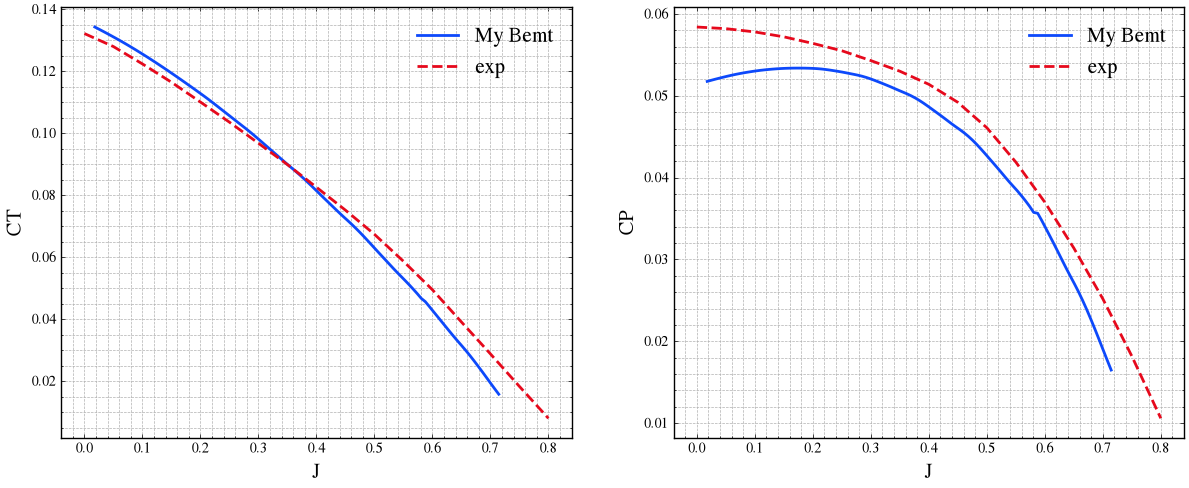

In [202]:
from NumOpt import Opti, ca
import numpy as np
import aerosandbox as asb
import gc
import subprocess
from pathlib import Path
import re as regex
import io
import pandas as pd


class Blade:
    def __init__(self, Rtip, radius_resolution, Nb, afmodel):
        self.rr = radius_resolution.reshape((1, -1))
        self.Rtip = Rtip
        self.Rhub = self.rr[0, 0] * self.Rtip
        self.Nb = Nb
        self.n_stator = self.rr.shape[1] - 2
        self.afmodel = afmodel

        self.residual, self.find_phi = self.gen_residual()

        self.solve_batch_func = self.gen_solve_batch()

    def mingw_jit(self):
        mingw_jit_options = {
            "jit": True,
            "jit_temp_suffix": True,
            # "jit_name":"bemt.c",
            "compiler": "shell",
            "jit_options": {
                "compiler": "gcc",  # Force GCC instead of cl.exe
                "linker": "gcc",  # Force GCC for linking
                "compiler_setup": "-fPIC -c",  # GNU compilation flags
                "linker_setup": "-shared",  # GNU linking flags
                "compiler_output_flag": "-o ",
                "linker_output_flag": "-o ",
                "flags": [
                    "-O3",
                    "-lm",
                    "-march=native",
                    "-ffast-math",
                    # "-flto",
                    # "-fopenmp",
                ],  # Optimize output code
                "verbose": True,
            },
        }
        return mingw_jit_options

    def gen_residual(self):
        mingw_jit = self.mingw_jit()

        r = self.rr[[0], 1:-1] * self.Rtip
        n_stator = self.n_stator
        Rhub = self.Rhub
        Rtip = self.Rtip
        Nb = self.Nb

        phi = ca.MX.sym("phi", 1, n_stator)
        Vx = ca.MX.sym("Vx")
        omega = ca.MX.sym("omega")
        chord = ca.MX.sym("chord", 1, n_stator)
        twist = ca.MX.sym("twist", 1, n_stator)
        pitch = ca.MX.sym("pitch")
        rho = ca.MX.sym("rho")
        mu = ca.MX.sym("mu")
        sos = ca.MX.sym("sos")

        Vy = omega * r

        W0 = np.sqrt(Vx**2 + Vy**2)
        Re = rho * W0 * chord / mu
        Mach = W0 / sos

        alpha = twist + pitch - phi
        alpha_deg = alpha / np.pi * 180.0
        CL, CD = self.afmodel(Reynold=Re, Mach=Mach, Alpha=alpha_deg, r=r)

        R, a, ap, Cn, Ct, F = self._residual(phi=phi, Vx=Vx, Vy=Vy, chord=chord, CL=CL, CD=CD, Rhub=Rhub, Rtip=Rtip, Nb=Nb, r=r)

        func = ca.Function(
            "residual_func",
            [phi, Vx, omega, chord, twist, pitch, rho, mu, sos],
            [R, a, ap, Cn, Ct, F],
            ["phi", "Vx", "omega", "chord", "twist", "pitch", "rho", "mu", "sos"],
            ["R", "a", "ap", "Cn", "Ct", "F"],
            # mingw_jit,
        )

        p_all = ca.vertcat(
            Vx,
            omega,
            chord.T,
            twist.T,
            pitch,
            rho,
            mu,
            sos,
        )

        mingw_jit["max_step"] = 5.0 / 180.0 * np.pi
        func_find_phi = ca.rootfinder(
            "find_phi",
            "newton",
            {"x": phi.T, "p": p_all, "g": R.T},
            {
                "max_step": 5.0 / 180.0 * np.pi,
                "max_iter": 500,
                "verbose": False,
                "line_search": False,
                "error_on_fail": True,
                # "abstol": 1e-4,
            },
            # mingw_jit,
        )

        return func, func_find_phi

    def solve(self, Vx, omega, chord, twist, pitch, rho, mu, sos):
        p_all = ca.vertcat(
            Vx,
            omega,
            chord[[0], 1:-1].T,
            twist[[0], 1:-1].T,
            pitch,
            rho,
            mu,
            sos,
        )
        r_val = self.rr[[0], 1:-1] * self.Rtip
        phi_guess = np.arctan2(Vx, omega * r_val).T
        phi_star = self.find_phi(x0=phi_guess, p=p_all)["x"]

        # phi_star = self.find_phi(x0=np.deg2rad(np.full((self.n_stator, 1), 10.0)), p=p_all)["x"]
        R = self.residual(phi=phi_star.T, Vx=Vx, omega=omega, chord=chord[[0], 1:-1], twist=twist[[0], 1:-1], pitch=pitch, rho=rho, mu=mu, sos=sos)
        a = R["a"]
        ap = R["ap"]
        Cn = R["Cn"]
        Ct = R["Ct"]

        phi_star = ca.horzcat(0.0, phi_star.T, 0.0)
        a = ca.horzcat(0.0, a, 0.0)
        ap = ca.horzcat(0.0, ap, 0.0)
        Cn = ca.horzcat(0.0, Cn, 0.0)
        Ct = ca.horzcat(0.0, Ct, 0.0)

        r = self.rr * self.Rtip
        Un = (1 + a) * Vx
        Ut = (1 - ap) * omega * r
        U2 = Un**2 + Ut**2

        dT = Cn * 0.5 * rho * U2 * chord * self.Nb
        dF = Ct * 0.5 * rho * U2 * chord * self.Nb
        dQ = dF * r

        T = self.integrate(r, dT)
        Q = self.integrate(r, dQ)
        P = Q * omega

        D = self.Rtip * 2
        n = omega / (2 * np.pi)
        CT = T / (rho * n**2 * D**4)
        CQ = Q / (rho * n**2 * D**5)
        CP = 2 * np.pi * CQ

        print(Vx, T)
        # print(phi_star)

        return {"phi": phi_star, "T": T, "Q": Q, "P": P, "CT": CT, "CQ": CQ, "CP": CP}

    def solve_batch(self, Vx, omega, chord, twist, pitch, rho, mu, sos):
        Vx = ca.reshape(Vx, (1, -1))
        omega = ca.reshape(omega, (1, -1))
        chord = ca.reshape(chord[[0], 1:-1], (-1, 1))
        twist = ca.reshape(twist[[0], 1:-1], (-1, 1))
        pitch = ca.reshape(pitch, (1, -1))
        rho = ca.reshape(rho, (1, -1))
        mu = ca.reshape(mu, (1, -1))
        sos = ca.reshape(sos, (1, -1))

        mpi = Vx.shape[1]
        solve_batch_func = self.solve_batch_func.map("solve_batch_func", "serial", mpi, ["omega", "chord", "twist", "pitch", "rho", "mu", "sos"], [], {})
        ret = solve_batch_func(Vx=Vx, omega=omega, chord=chord, twist=twist, pitch=pitch, rho=rho, mu=mu, sos=sos)
        print(ret["T"])

    def gen_solve_batch(self):
        Vx = ca.MX.sym("Vx")
        omega = ca.MX.sym("omega")
        chord = ca.MX.sym("chord", 1, self.n_stator + 2)
        twist = ca.MX.sym("twist", 1, self.n_stator + 2)
        pitch = ca.MX.sym("pitch")
        rho = ca.MX.sym("rho")
        mu = ca.MX.sym("rho")
        sos = ca.MX.sym("sos")

        p_all = ca.vertcat(
            Vx,
            omega,
            chord[[0], 1:-1].T,
            twist[[0], 1:-1].T,
            pitch,
            rho,
            mu,
            sos,
        )
        r_val = self.rr[[0], 1:-1] * self.Rtip
        phi_guess = ca.atan2(Vx, omega * r_val).T
        phi_star = self.find_phi(x0=phi_guess, p=p_all)["x"]

        phi_star = self.find_phi(x0=np.deg2rad(np.full((self.n_stator, 1), 10.0)), p=p_all)["x"]
        R = self.residual(phi=phi_star.T, Vx=Vx, omega=omega, chord=chord[[0], 1:-1], twist=twist[[0], 1:-1], pitch=pitch, rho=rho, mu=mu, sos=sos)
        a = R["a"]
        ap = R["ap"]
        Cn = R["Cn"]
        Ct = R["Ct"]

        phi_star = ca.horzcat(0.0, phi_star.T, 0.0)
        a = ca.horzcat(0.0, a, 0.0)
        ap = ca.horzcat(0.0, ap, 0.0)
        Cn = ca.horzcat(0.0, Cn, 0.0)
        Ct = ca.horzcat(0.0, Ct, 0.0)

        r = self.rr * self.Rtip
        Un = (1 + a) * Vx
        Ut = (1 - ap) * omega * r
        U2 = Un**2 + Ut**2

        dT = Cn * 0.5 * rho * U2 * chord * self.Nb
        dF = Ct * 0.5 * rho * U2 * chord * self.Nb
        dQ = dF * r

        T = self.integrate(r, dT)
        Q = self.integrate(r, dQ)
        P = Q * omega

        D = self.Rtip * 2
        n = omega / (2 * np.pi)
        CT = T / (rho * n**2 * D**4)
        CQ = Q / (rho * n**2 * D**5)
        CP = 2 * np.pi * CQ

        # mingw_jit = self.mingw_jit()

        func = ca.Function(
            "solve",
            [Vx, omega, chord.T, twist.T, pitch, rho, mu, sos],
            [T, Q, P, CT, CQ, CP],
            ["Vx", "omega", "chord", "twist", "pitch", "rho", "mu", "sos"],
            ["T", "Q", "P", "CT", "CQ", "CP"],
            # mingw_jit,
        )
        return func

    @staticmethod
    def integrate(x, f):
        dx = ca.diff(x, 1)
        f_center = (f[0, :-1] + f[0, 1:]) / 2.0
        T_tot = ca.dot(dx, f_center)
        return T_tot

    @staticmethod
    def _residual(phi, Vx, Vy, chord, CL, CD, Rhub, Rtip, Nb, r):
        def prantl_loss(phi, r, Rhub, Rtip, Nb):
            sphi = ca.fabs(ca.sin(phi)) + 1e-9

            ftip = Nb / 2.0 * (Rtip - r) / (r * sphi)
            Ftip = (2.0 / np.pi) * ca.arccos(ca.exp(-ftip))

            fhub = Nb / 2.0 * (r - Rhub) / (Rhub * sphi)
            Fhub = 2.0 / np.pi * ca.arccos(np.exp(-fhub))

            F = Ftip * Fhub
            # F=1.0

            return F

        def axial_induction(k, phi):
            k = ca.if_else(phi < 0.0, -k, k)
            a_normal = k / (1 - k)
            g1 = 2 * k + 1.0 / 9
            # g2 = ca.fmax(-2 * k - 1.0 / 3, 1e-9)
            g2=-2 * k - 1.0 / 3
            g3 = -2 * k - 7.0 / 9
            a_buhl = (g1 + ca.sqrt(g2)) / g3
            a = ca.if_else(k >= -2 / 3, a_normal, a_buhl)
            invalid = ca.fabs(k - 1.0) < 1e-9
            return a, invalid


        def tangential_induction(kp, Vx):
            kp = ca.if_else(Vx < 0.0, -kp, kp)
            ap = kp / (1 + kp)
            invaild = ca.fabs(kp + 1.0) < 1e-9
            return ap, invaild

        phi_sin = ca.sin(phi)
        phi_cos = ca.cos(phi)

        solidity = Nb * chord / (2 * np.pi * r)

        Cn = CL * phi_cos - CD * phi_sin
        Ct = CL * phi_sin + CD * phi_cos

        F = prantl_loss(phi=phi, r=r, Rhub=Rhub, Rtip=Rtip, Nb=Nb)
        # F = 1.0

        k = Cn * solidity / (4 * F * phi_sin**2 + 1e-9)
        kp = Ct * solidity / (4 * F * phi_sin * phi_cos + 1e-9)

        # a = k / (1 - k)
        # ap = kp / (1 + kp) 

        a, inv_a = axial_induction(k=k, phi=phi)
        ap, inv_ap = tangential_induction(kp=kp, Vx=Vx)
        invaild = ca.logic_or(inv_a, inv_ap)
        R_reg = np.sin(phi) / (1 + a) - Vx / Vy * np.cos(phi) / (1 - ap)
        R = ca.if_else(invaild, 1.0, R_reg)

        return R, a, ap, Cn, Ct, F


class FileAirfoil:
    def __init__(self, csvfile):
        # self.air_data = np.loadtxt(csvfile, ndmin=2)
        self.air_data = self.read_af_cfd(csvfile)
        self.rlist = np.array([0.375, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, 3.054 / 2.0])
        dataset = []
        for r in self.rlist:
            df = pd.DataFrame({"r": r, "alpha": self.air_data[:, 0], "CL": self.air_data[:, 1], "CD": self.air_data[:, 2]})
            dataset.append(df)
        dataset = pd.concat(dataset, axis=0, ignore_index=True)
        dataset = dataset.sort_values(by=["r", "alpha"])
        dataset = dataset.set_index(["r", "alpha"])
        ds = dataset.to_xarray()
        # print(ds.sel(r=0.525,alpha=-180.0))
        self.CL_model = ca.interpolant("CL_model", "bspline", [ds["r"].values, ds["alpha"].values], ds["CL"].values.ravel(order="F"))
        self.CD_model = ca.interpolant("CD_model", "bspline", [ds["r"].values, ds["alpha"].values], ds["CD"].values.ravel(order="F"))
        # self.CL_model=ca.interpolant("CL_model","linear",[self.air_data[:,0]],self.air_data[:,1])
        # self.CD_model=ca.interpolant("CD_model","linear",[self.air_data[:,0]],self.air_data[:,2])

    def __call__(self, Alpha=None, Reynold=None, Mach=None, r=None, opti=None):
        """
        alpha: deg

        """
        coord = ca.vcat([r, Alpha])
        cl = self.CL_model(coord)
        cd = self.CD_model(coord)
        return cl, cd

    def read_af_cfd(self, csvfile):
        pattern = r"^\s*(-?\d+.?\d+\s*)(-?\d+.?\d+\s*)*(-?\d+.?\d+\s*)$"
        pattern = regex.compile(pattern)
        with open(csvfile, "r") as fin:
            content = fin.readlines()
        for idx_line, line in enumerate(content):
            match_res = regex.match(pattern, line)
            if match_res is not None:
                idx_data = idx_line
                break
        data = np.loadtxt(io.StringIO("".join(content[idx_data:])), ndmin=2)
        return data


af_model = FileAirfoil(csvfile="../BEM/pyBEMT/pybemt/airfoils/CLARKY.dat")
chord = np.array([0.18, 0.18, 0.225, 0.225, 0.21, 0.1875, 0.1425, 0.12, 0.12]).reshape((1, -1))
twist = np.deg2rad(np.array([17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0])).reshape((1, -1))

Rtip = 3.054 / 2.0
Rhub = 0.375
r = np.array([Rhub, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, Rtip]).reshape((1, -1))
sos = 340.0
mu = 0.0000181
rho = 1.225

rotor = Blade(Rtip=Rtip, radius_resolution=r / Rtip, Nb=3, afmodel=FileAirfoil(csvfile="../BEM/pyBEMT/pybemt/airfoils/CLARKY.dat"))

aero_list=[]
vinf_list = np.linspace(1.0, 40.0, 100)
for vx in vinf_list:
    print("vinf: ",vx)
    aero=rotor.solve(Vx=vx, omega=1100 * 2 * np.pi / 60.0, chord=chord, twist=twist, pitch=0.0, rho=rho, mu=mu, sos=sos)
    aero_list.append(aero)

import matplotlib.pyplot as plt 
import scienceplots 

CT=ca.vcat([i["CT"] for i in aero_list])

CP=ca.vcat([i["CP"] for i in aero_list])

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(12, 5))
        ax = fig.add_subplot(121)
        ax.plot(vinf_list / (1100 / 60 * 2 * Rtip), CT, label="My Bemt")
        # print([i["CT"] for i in ret_list])

        exp_data = np.loadtxt("../BEM/propeller_dat.csv", skiprows=1, ndmin=2)
        ax.plot(exp_data[:, 0], exp_data[:, 1], label="exp")
        ax.set_xlabel("J")
        ax.set_ylabel("CT")
        ax.legend(fontsize=15)
        # ax.grid(True,"both",linestyle="-")

        ax = fig.add_subplot(122)
        ax.plot(vinf_list / (1100 / 60 * 2 * Rtip), CP, label="My Bemt")
        # print([i["CT"] for i in ret_list])

        exp_data = np.loadtxt("../BEM/propeller_dat.csv", skiprows=1, ndmin=2)
        ax.plot(exp_data[:, 0], exp_data[:, 2], label="exp")
        ax.set_xlabel("J")
        ax.set_ylabel("CP")
        # ax.set_ylim(bottom=0.0, top=0.14)
        ax.legend(fontsize=15)
        # ax.grid(True,"both",linestyle="-")
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        # plt.savefig("./runtime/pic01.png", dpi=300, transparent=True)
        plt.show()

# test 2

In [206]:
from NumOpt import Opti, ca
import numpy as np
import aerosandbox as asb
import gc
import subprocess
from pathlib import Path
import re as regex
import io
import pandas as pd


class Blade:
    def __init__(self, Rtip, radius_resolution, Nb, afmodel):
        self.rr = radius_resolution.reshape((1, -1))
        self.Rtip = Rtip
        self.Rhub = self.rr[0, 0] * self.Rtip
        self.Nb = Nb
        self.n_stator = self.rr.shape[1] - 2
        self.afmodel = afmodel

        self.residual, self.find_phi = self.gen_residual()

        self.solve_batch_func = self.gen_solve_batch()

    def mingw_jit(self):
        mingw_jit_options = {
            "jit": True,
            "jit_temp_suffix": True,
            # "jit_name":"bemt.c",
            "compiler": "shell",
            "jit_options": {
                "compiler": "gcc",  # Force GCC instead of cl.exe
                "linker": "gcc",  # Force GCC for linking
                "compiler_setup": "-fPIC -c",  # GNU compilation flags
                "linker_setup": "-shared",  # GNU linking flags
                "compiler_output_flag": "-o ",
                "linker_output_flag": "-o ",
                "flags": [
                    "-O3",
                    "-lm",
                    "-march=native",
                    "-ffast-math",
                    # "-flto",
                    # "-fopenmp",
                ],  # Optimize output code
                "verbose": True,
            },
        }
        return mingw_jit_options

    def gen_residual(self):
        mingw_jit = self.mingw_jit()

        r = self.rr[[0], 1:-1] * self.Rtip
        n_stator = self.n_stator
        Rhub = self.Rhub
        Rtip = self.Rtip
        Nb = self.Nb

        phi = ca.MX.sym("phi", 1, n_stator)
        Vx = ca.MX.sym("Vx")
        omega = ca.MX.sym("omega")
        chord = ca.MX.sym("chord", 1, n_stator)
        twist = ca.MX.sym("twist", 1, n_stator)
        pitch = ca.MX.sym("pitch")
        rho = ca.MX.sym("rho")
        mu = ca.MX.sym("mu")
        sos = ca.MX.sym("sos")

        Vy = omega * r

        W0 = np.sqrt(Vx**2 + Vy**2)
        Re = rho * W0 * chord / mu
        Mach = W0 / sos

        alpha = twist + pitch - phi
        alpha_deg = alpha / np.pi * 180.0
        CL, CD = self.afmodel(Reynold=Re, Mach=Mach, Alpha=alpha_deg, r=r)

        R, a, ap, Cn, Ct, F = self._residual(phi=phi, Vx=Vx, Vy=Vy, chord=chord, CL=CL, CD=CD, Rhub=Rhub, Rtip=Rtip, Nb=Nb, r=r)

        func = ca.Function(
            "residual_func",
            [phi, Vx, omega, chord, twist, pitch, rho, mu, sos],
            [R, a, ap, Cn, Ct, F],
            ["phi", "Vx", "omega", "chord", "twist", "pitch", "rho", "mu", "sos"],
            ["R", "a", "ap", "Cn", "Ct", "F"],
            # mingw_jit,
        )

        p_all = ca.vertcat(
            Vx,
            omega,
            chord.T,
            twist.T,
            pitch,
            rho,
            mu,
            sos,
        )

        mingw_jit["max_step"] = 5.0 / 180.0 * np.pi
        func_find_phi = ca.rootfinder(
            "find_phi",
            "newton",
            {"x": phi.T, "p": p_all, "g": R.T},
            {
                "max_step": 10.0 / 180.0 * np.pi,
                "max_iter": 500,
                "verbose": False,
                "line_search": True,
                "error_on_fail": False,
                # "abstol": 1e-4,
            },
            # mingw_jit,
        )

        return func, func_find_phi

    def solve(self, Vx, omega, chord, twist, pitch, rho, mu, sos):
        p_all = ca.vertcat(
            Vx,
            omega,
            chord[[0], 1:-1].T,
            twist[[0], 1:-1].T,
            pitch,
            rho,
            mu,
            sos,
        )
        r_val = self.rr[[0], 1:-1] * self.Rtip
        phi_guess = np.arctan2(Vx, omega * r_val).T
        phi_star = self.find_phi(x0=phi_guess, p=p_all)["x"]

        # phi_star = self.find_phi(x0=np.deg2rad(np.full((self.n_stator, 1), 10.0)), p=p_all)["x"]
        R = self.residual(phi=phi_star.T, Vx=Vx, omega=omega, chord=chord[[0], 1:-1], twist=twist[[0], 1:-1], pitch=pitch, rho=rho, mu=mu, sos=sos)
        a = R["a"]
        ap = R["ap"]
        Cn = R["Cn"]
        Ct = R["Ct"]

        phi_star = ca.horzcat(0.0, phi_star.T, 0.0)
        a = ca.horzcat(0.0, a, 0.0)
        ap = ca.horzcat(0.0, ap, 0.0)
        Cn = ca.horzcat(0.0, Cn, 0.0)
        Ct = ca.horzcat(0.0, Ct, 0.0)

        r = self.rr * self.Rtip
        Un = (1 + a) * Vx
        Ut = (1 - ap) * omega * r
        U2 = Un**2 + Ut**2

        dT = Cn * 0.5 * rho * U2 * chord * self.Nb
        dF = Ct * 0.5 * rho * U2 * chord * self.Nb
        dQ = dF * r

        T = self.integrate(r, dT)
        Q = self.integrate(r, dQ)
        P = Q * omega

        D = self.Rtip * 2
        n = omega / (2 * np.pi)
        CT = T / (rho * n**2 * D**4)
        CQ = Q / (rho * n**2 * D**5)
        CP = 2 * np.pi * CQ

        print(Vx, T)
        # print(phi_star)

        return {"phi": phi_star, "T": T, "Q": Q, "P": P, "CT": CT, "CQ": CQ, "CP": CP}

    def solve_batch(self, Vx, omega, chord, twist, pitch, rho, mu, sos):
        Vx = ca.reshape(Vx, (1, -1))
        omega = ca.reshape(omega, (1, -1))
        chord = ca.reshape(chord[[0], 1:-1], (-1, 1))
        twist = ca.reshape(twist[[0], 1:-1], (-1, 1))
        pitch = ca.reshape(pitch, (1, -1))
        rho = ca.reshape(rho, (1, -1))
        mu = ca.reshape(mu, (1, -1))
        sos = ca.reshape(sos, (1, -1))

        mpi = Vx.shape[1]
        solve_batch_func = self.solve_batch_func.map("solve_batch_func", "serial", mpi, ["omega", "chord", "twist", "pitch", "rho", "mu", "sos"], [], {})
        ret = solve_batch_func(Vx=Vx, omega=omega, chord=chord, twist=twist, pitch=pitch, rho=rho, mu=mu, sos=sos)
        print(ret["T"])

    def gen_solve_batch(self):
        Vx = ca.MX.sym("Vx")
        omega = ca.MX.sym("omega")
        chord = ca.MX.sym("chord", 1, self.n_stator + 2)
        twist = ca.MX.sym("twist", 1, self.n_stator + 2)
        pitch = ca.MX.sym("pitch")
        rho = ca.MX.sym("rho")
        mu = ca.MX.sym("rho")
        sos = ca.MX.sym("sos")

        p_all = ca.vertcat(
            Vx,
            omega,
            chord[[0], 1:-1].T,
            twist[[0], 1:-1].T,
            pitch,
            rho,
            mu,
            sos,
        )
        r_val = self.rr[[0], 1:-1] * self.Rtip
        phi_guess = ca.atan2(Vx, omega * r_val).T
        phi_star = self.find_phi(x0=phi_guess, p=p_all)["x"]

        phi_star = self.find_phi(x0=np.deg2rad(np.full((self.n_stator, 1), 10.0)), p=p_all)["x"]
        R = self.residual(phi=phi_star.T, Vx=Vx, omega=omega, chord=chord[[0], 1:-1], twist=twist[[0], 1:-1], pitch=pitch, rho=rho, mu=mu, sos=sos)
        a = R["a"]
        ap = R["ap"]
        Cn = R["Cn"]
        Ct = R["Ct"]

        phi_star = ca.horzcat(0.0, phi_star.T, 0.0)
        a = ca.horzcat(0.0, a, 0.0)
        ap = ca.horzcat(0.0, ap, 0.0)
        Cn = ca.horzcat(0.0, Cn, 0.0)
        Ct = ca.horzcat(0.0, Ct, 0.0)

        r = self.rr * self.Rtip
        Un = (1 + a) * Vx
        Ut = (1 - ap) * omega * r
        U2 = Un**2 + Ut**2

        dT = Cn * 0.5 * rho * U2 * chord * self.Nb
        dF = Ct * 0.5 * rho * U2 * chord * self.Nb
        dQ = dF * r

        T = self.integrate(r, dT)
        Q = self.integrate(r, dQ)
        P = Q * omega

        D = self.Rtip * 2
        n = omega / (2 * np.pi)
        CT = T / (rho * n**2 * D**4)
        CQ = Q / (rho * n**2 * D**5)
        CP = 2 * np.pi * CQ

        # mingw_jit = self.mingw_jit()

        func = ca.Function(
            "solve",
            [Vx, omega, chord.T, twist.T, pitch, rho, mu, sos],
            [T, Q, P, CT, CQ, CP],
            ["Vx", "omega", "chord", "twist", "pitch", "rho", "mu", "sos"],
            ["T", "Q", "P", "CT", "CQ", "CP"],
            # mingw_jit,
        )
        return func

    @staticmethod
    def integrate(x, f):
        dx = ca.diff(x, 1)
        f_center = (f[0, :-1] + f[0, 1:]) / 2.0
        T_tot = ca.dot(dx, f_center)
        return T_tot

    @staticmethod
    def _residual(phi, Vx, Vy, chord, CL, CD, Rhub, Rtip, Nb, r):
        def prantl_loss(phi, r, Rhub, Rtip, Nb):
            sphi = ca.fabs(ca.sin(phi)) + 1e-9

            ftip = Nb / 2.0 * (Rtip - r) / (r * sphi)
            Ftip = (2.0 / np.pi) * ca.arccos(ca.exp(-ftip))

            fhub = Nb / 2.0 * (r - Rhub) / (Rhub * sphi)
            Fhub = 2.0 / np.pi * ca.arccos(np.exp(-fhub))

            F = Ftip * Fhub
            # F=1.0

            return F

        def axial_induction(k, phi):
            k = ca.if_else(phi < 0.0, -k, k)
            a_normal = k / (1 - k)
            g1 = 2 * k + 1.0 / 9
            # g2 = ca.fmax(-2 * k - 1.0 / 3, 1e-9)
            g2=-2 * k - 1.0 / 3
            g3 = -2 * k - 7.0 / 9
            a_buhl = (g1 + ca.sqrt(g2)) / g3
            a = ca.if_else(k >= -2 / 3, a_normal, a_buhl)
            invalid = ca.fabs(k - 1.0) < 1e-9
            return a, invalid


        def tangential_induction(kp, Vx):
            kp = ca.if_else(Vx < 0.0, -kp, kp)
            ap = kp / (1 + kp)
            invaild = ca.fabs(kp + 1.0) < 1e-9
            return ap, invaild

        phi_sin = ca.sin(phi)
        phi_cos = ca.cos(phi)

        solidity = Nb * chord / (2 * np.pi * r)

        Cn = CL * phi_cos - CD * phi_sin
        Ct = CL * phi_sin + CD * phi_cos

        F = prantl_loss(phi=phi, r=r, Rhub=Rhub, Rtip=Rtip, Nb=Nb)
        # F = 1.0

        k = Cn * solidity / (4 * F * phi_sin**2 + 1e-9)
        kp = Ct * solidity / (4 * F * phi_sin * phi_cos + 1e-9)

        # a = k / (1 - k)
        # ap = kp / (1 + kp) 

        a, inv_a = axial_induction(k=k, phi=phi)
        ap, inv_ap = tangential_induction(kp=kp, Vx=Vx)
        invaild = ca.logic_or(inv_a, inv_ap)
        R_reg = np.sin(phi) / (1 + a) - Vx / Vy * np.cos(phi) / (1 - ap)
        R = ca.if_else(invaild, 1.0, R_reg)

        return R, a, ap, Cn, Ct, F



class FileAirfoil:
    def __init__(self, Rtip):
        self.Rtip = Rtip
        self.stator = np.array([0.0, 0.2, 0.5, 0.75, 1.0])
        self.af = asb.Airfoil("clarky")

    def __call__(self, Alpha=None, Reynold=None, Mach=None, r=None, opti=None):
        rr = r / self.Rtip
        idx = np.searchsorted(self.stator, rr.ravel(), side="left")
        left = self.stator[idx - 1]
        right = self.stator[idx]

        dr = right - left
        dr_left = rr - left
        dr_right = right - rr

        w_left = dr_right / dr
        w_right = dr_left / dr

        aero_left = self.af.get_aero_from_neuralfoil(alpha=Alpha.T, mach=Mach.T, Re=Reynold.T, model_size="large")
        aero_right = self.af.get_aero_from_neuralfoil(alpha=Alpha.T, mach=Mach.T, Re=Reynold.T, model_size="large")
        cl = aero_left["CL"].T * w_left + aero_right["CL"].T * w_right
        cd = aero_left["CD"].T * w_left + aero_right["CD"].T * w_right

        return cl, cd


chord = np.array([0.18, 0.18, 0.225, 0.225, 0.21, 0.1875, 0.1425, 0.12, 0.12]).reshape((1, -1))
twist = np.deg2rad(np.array([17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0])).reshape((1, -1))

Rtip = 3.054 / 2.0
Rhub = 0.375
r = np.array([Rhub, 0.525, 0.675, 0.825, 0.975, 1.125, 1.275, 1.425, Rtip]).reshape((1, -1))
sos = 340.0
mu = 0.0000181
rho = 1.225

rotor = Blade(Rtip=Rtip, radius_resolution=r / Rtip, Nb=3, afmodel=FileAirfoil(Rtip=Rtip))
solve_bacth=rotor.solve_batch_func.map("solve_map","openmp",100,["omega","chord","twist","pitch","rho","mu","sos"],[],{})

vinf:  1.0
1.0 5164.79
vinf:  1.4343434343434343
1.4343434343434343 5134.26
vinf:  1.8686868686868687
1.8686868686868687 5103.15
vinf:  2.303030303030303
2.303030303030303 5071.48
vinf:  2.7373737373737375
2.7373737373737375 5039.28
vinf:  3.1717171717171717
3.1717171717171717 5006.58
vinf:  3.6060606060606064
3.6060606060606064 4973.38
vinf:  4.040404040404041
4.040404040404041 4939.7
vinf:  4.474747474747475
4.474747474747475 4905.55
vinf:  4.909090909090909
4.909090909090909 4870.95
vinf:  5.343434343434343
5.343434343434343 4835.89
vinf:  5.777777777777778
5.777777777777778 4800.37
vinf:  6.212121212121213
6.212121212121213 4764.41
vinf:  6.646464646464647
6.646464646464647 4728
vinf:  7.080808080808081
7.080808080808081 4691.14
vinf:  7.515151515151516
7.515151515151516 4653.82
vinf:  7.94949494949495
7.94949494949495 4616.03
vinf:  8.383838383838384
8.383838383838384 4577.77
vinf:  8.818181818181818
8.818181818181818 4539.03
vinf:  9.252525252525253
9.252525252525253 4499.79
vinf

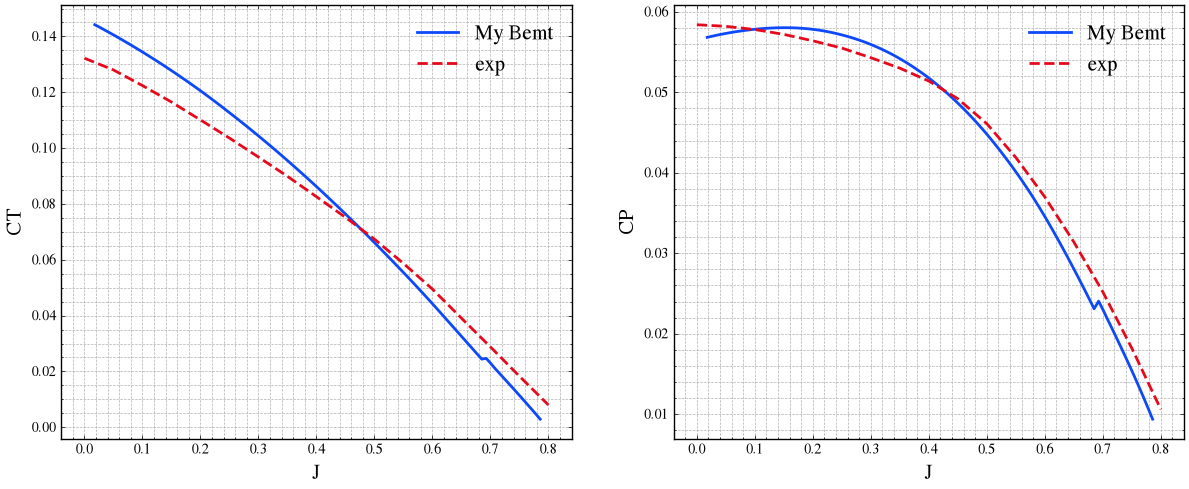

In [207]:
aero_list = []
vinf_list = np.linspace(1.0, 44.0, 100)
# vinf_list=np.array([33.0,34.0,35.2, 36.282051282051285,37.0])
for vx in vinf_list:
    print("vinf: ",vx)
    aero = rotor.solve(Vx=vx, omega=1100 * 2 * np.pi / 60.0, chord=chord, twist=twist, pitch=0.0, rho=rho, mu=mu, sos=sos)
    # aero = rotor.solve_batch_func(Vx=vx, omega=1100 * 2 * np.pi / 60.0, chord=chord.T, twist=twist.T, pitch=0.0, rho=rho, mu=mu, sos=sos)
    aero_list.append(aero)

import matplotlib.pyplot as plt
import scienceplots

CT = ca.vcat([i["CT"] for i in aero_list])

CP = ca.vcat([i["CP"] for i in aero_list])

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(12, 5))
        ax = fig.add_subplot(121)
        ax.plot(vinf_list / (1100 / 60 * 2 * Rtip), CT, label="My Bemt")
        # print([i["CT"] for i in ret_list])

        exp_data = np.loadtxt("../BEM/propeller_dat.csv", skiprows=1, ndmin=2)
        ax.plot(exp_data[:, 0], exp_data[:, 1], label="exp")
        ax.set_xlabel("J")
        ax.set_ylabel("CT")
        ax.legend(fontsize=15)
        # ax.grid(True,"both",linestyle="-")

        ax = fig.add_subplot(122)
        ax.plot(vinf_list / (1100 / 60 * 2 * Rtip), CP, label="My Bemt")
        # print([i["CT"] for i in ret_list])

        exp_data = np.loadtxt("../BEM/propeller_dat.csv", skiprows=1, ndmin=2)
        ax.plot(exp_data[:, 0], exp_data[:, 2], label="exp")
        ax.set_xlabel("J")
        ax.set_ylabel("CP")
        # ax.set_ylim(bottom=0.0, top=0.14)
        ax.legend(fontsize=15)
        # ax.grid(True,"both",linestyle="-")
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        # plt.savefig("./runtime/pic01.png", dpi=300, transparent=True)
        plt.show()

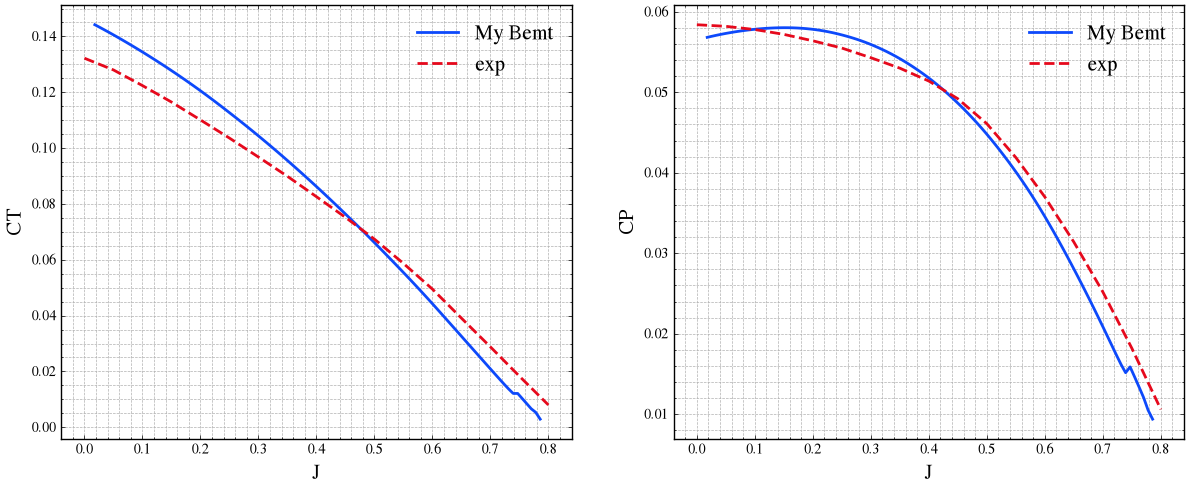

In [208]:
# 

vinf_list = np.linspace(1.0, 44.0, 100)
aero = solve_bacth(Vx=vinf_list.reshape((1,-1)), omega=1100 * 2 * np.pi / 60.0, chord=chord.T, twist=twist.T, pitch=0.0, rho=rho, mu=mu, sos=sos)



# aero_list = []
# vinf_list = np.linspace(1.0, 44.0, 20)
# for vx in vinf_list:
#     aero = rotor.solve(Vx=vx, omega=1100 * 2 * np.pi / 60.0, chord=chord, twist=twist, pitch=0.0, rho=rho, mu=mu, sos=sos)
#     # aero = rotor.solve_batch_func(Vx=vx, omega=1100 * 2 * np.pi / 60.0, chord=chord.T, twist=twist.T, pitch=0.0, rho=rho, mu=mu, sos=sos)
#     aero_list.append(aero)

import matplotlib.pyplot as plt
import scienceplots

# CT = ca.vcat([i["CT"] for i in aero_list])
# CP = ca.vcat([i["CP"] for i in aero_list])
CT=aero["CT"].toarray().ravel()
CP=aero["CP"].toarray().ravel()

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(12, 5))
        ax = fig.add_subplot(121)
        ax.plot(vinf_list / (1100 / 60 * 2 * Rtip), CT, label="My Bemt")
        # print([i["CT"] for i in ret_list])

        exp_data = np.loadtxt("../BEM/propeller_dat.csv", skiprows=1, ndmin=2)
        ax.plot(exp_data[:, 0], exp_data[:, 1], label="exp")
        ax.set_xlabel("J")
        ax.set_ylabel("CT")
        ax.legend(fontsize=15)
        # ax.grid(True,"both",linestyle="-")

        ax = fig.add_subplot(122)
        ax.plot(vinf_list / (1100 / 60 * 2 * Rtip), CP, label="My Bemt")
        # print([i["CT"] for i in ret_list])

        exp_data = np.loadtxt("../BEM/propeller_dat.csv", skiprows=1, ndmin=2)
        ax.plot(exp_data[:, 0], exp_data[:, 2], label="exp")
        ax.set_xlabel("J")
        ax.set_ylabel("CP")
        # ax.set_ylim(bottom=0.0, top=0.14)
        ax.legend(fontsize=15)
        # ax.grid(True,"both",linestyle="-")
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        # plt.savefig("./runtime/pic01.png", dpi=300, transparent=True)
        plt.show()

In [2]:
del rotor 
import gc 
gc.collect()

1065

In [1]:
from NumOpt import ca 

x=ca.MX.sym("x")
p=ca.MX.sym("p")
g=x**2-p 

rfp:ca.Function=ca.rootfinder("rfp","fast_newton",{"x":x,"p":p,"g":g},{"max_step":0.5})
rfp.generate("rfp.c")
# rfp(x0=1.0,p=8.0)


# ! gcc -O3 -fPIC -shared -o rfp.dll rfp.c

'rfp.c'

In [1]:
import casadi as ca
import numpy as np
import subprocess

x = ca.MX.sym("x")
y = ca.MX.sym("y")

mingw_jit_options = {
    "jit": True,
    "compiler": "shell",
    "jit_options": {
        "compiler": "gcc",  # Force GCC instead of cl.exe
        "linker": "gcc",  # Force GCC for linking
        "compiler_setup": "-fPIC -c",  # GNU compilation flags
        "linker_setup": "-shared",  # GNU linking flags
        "compiler_output_flag": "-o ",
        "linker_output_flag": "-o ",
        "flags": [
            "-O3",
            "-lm" "-march=native",
            "-ffast-math",
            # "-flto",
            # "-fopenmp",
        ],  # Optimize output code
        "verbose": True,
    },
}

funcb = ca.Function("funcb", [x], [ca.sin(x)], ["x"], ["y"], mingw_jit_options)
# funcb.generate("funcb")
# ! gcc -fPIC -shared -O3 -o funcb.dll funcb.c

CasADi - 2026-08-18 22:03:10 MESSAGE("calling "gcc -O3 -lm-march=native -ffast-math -fPIC -c jit_tmpj018y4.c -o tmp_casadi_compiler_shell37gvnt.obj"") [.../casadi/solvers/shell_compiler.cpp:229]
CasADi - 2026-08-18 22:03:11 MESSAGE("calling "gcc tmp_casadi_compiler_shell37gvnt.obj -o tmp_casadi_compiler_shell37gvnt.dll -shared"") [.../casadi/solvers/shell_compiler.cpp:248]


In [6]:
import casadi as ca
import numpy as np
import subprocess

x = ca.MX.sym("x",6,1)
y=ca.sum(x)
func=ca.Function("func",[x],[y])

In [6]:
from NumOpt import ca,Opti,np
x=ca.MX.sym("x")
func=ca.Function("func",[x],[ca.sin(x)])
func.generate("func.c")
# rfp:ca.Function=ca.rootfinder("rfp","newton",{"x":x,"g":ca.sin(x)-0.5})
# rfp.generate("rpf.c")
! gcc -O3 -lm -fPIC -shared -o func.dll func.c

D:/Portable/mingw64/bin/../lib/gcc/x86_64-w64-mingw32/16.1.0/../../../../x86_64-w64-mingw32/bin/ld.exe: cannot open output file func.dll: Permission denied
collect2.exe: error: ld returned 1 exit status


[[ 0.1387  7.835 ]
 [ 0.5375 19.375 ]
 [ 0.6192 18.36  ]
 [ 0.7904 13.12  ]
 [ 0.8883  9.315 ]]

[[0.1387, 7.835], 
 [0.5375, 19.375], 
 [0.6192, 18.36], 
 [0.7904, 13.12], 
 [0.8883, 9.315]]


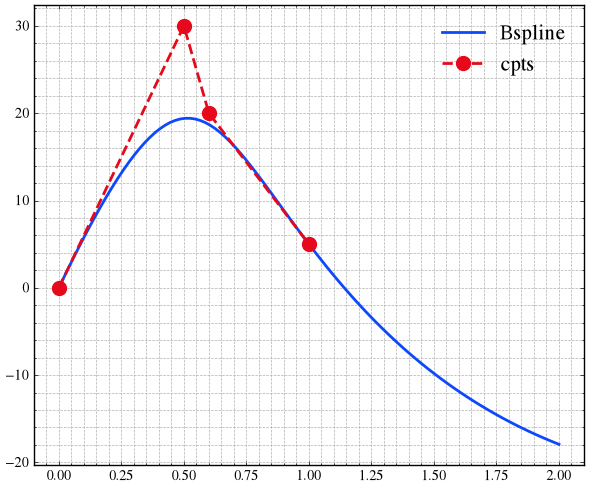

In [1]:
from NumOpt import ca,Opti,np 
import numpy as np
import aerosandbox as asb
import gc
import subprocess
from pathlib import Path
import re as regex
import io
import pandas as pd


class Blade:
    def __init__(self, Rtip, radius_resolution, Nb, afmodel):
        self.rr = radius_resolution.reshape((1, -1))
        self.Rtip = Rtip
        self.Rhub = self.rr[0, 0] * self.Rtip
        self.Nb = Nb
        self.n_stator = self.rr.shape[1] - 2
        self.afmodel = afmodel

        self.residual, self.find_phi = self.gen_residual()

        self.solve_batch_func = self.gen_solve_batch()

    def mingw_jit(self):
        mingw_jit_options = {
            "jit": True,
            "jit_temp_suffix": True,
            # "jit_name":"bemt.c",
            "compiler": "shell",
            "jit_options": {
                "compiler": "gcc",  # Force GCC instead of cl.exe
                "linker": "gcc",  # Force GCC for linking
                "compiler_setup": "-fPIC -c",  # GNU compilation flags
                "linker_setup": "-shared",  # GNU linking flags
                "compiler_output_flag": "-o ",
                "linker_output_flag": "-o ",
                "flags": [
                    "-O3",
                    "-lm",
                    "-march=native",
                    "-ffast-math",
                    # "-flto",
                    # "-fopenmp",
                ],  # Optimize output code
                "verbose": True,
            },
        }
        return mingw_jit_options

    def gen_residual(self):
        mingw_jit = self.mingw_jit()

        r = self.rr[[0], 1:-1] * self.Rtip
        n_stator = self.n_stator
        Rhub = self.Rhub
        Rtip = self.Rtip
        Nb = self.Nb

        phi = ca.MX.sym("phi", 1, n_stator)
        Vx = ca.MX.sym("Vx")
        omega = ca.MX.sym("omega")
        chord = ca.MX.sym("chord", 1, n_stator)
        twist = ca.MX.sym("twist", 1, n_stator)
        pitch = ca.MX.sym("pitch")
        rho = ca.MX.sym("rho")
        mu = ca.MX.sym("mu")
        sos = ca.MX.sym("sos")

        Vy = omega * r

        W0 = np.sqrt(Vx**2 + Vy**2)
        Re = rho * W0 * chord / mu
        Mach = W0 / sos

        alpha = twist + pitch - phi
        alpha_deg = alpha / np.pi * 180.0
        CL, CD = self.afmodel(Reynold=Re, Mach=Mach, Alpha=alpha_deg, r=r)

        R, a, ap, Cn, Ct, F = self._residual(phi=phi, Vx=Vx, Vy=Vy, chord=chord, CL=CL, CD=CD, Rhub=Rhub, Rtip=Rtip, Nb=Nb, r=r)

        func = ca.Function(
            "residual_func",
            [phi, Vx, omega, chord, twist, pitch, rho, mu, sos],
            [R, a, ap, Cn, Ct, F],
            ["phi", "Vx", "omega", "chord", "twist", "pitch", "rho", "mu", "sos"],
            ["R", "a", "ap", "Cn", "Ct", "F"],
            # mingw_jit,
        )

        p_all = ca.vertcat(
            Vx,
            omega,
            chord.T,
            twist.T,
            pitch,
            rho,
            mu,
            sos,
        )

        mingw_jit["max_step"] = 5.0 / 180.0 * np.pi
        func_find_phi = ca.rootfinder(
            "find_phi",
            "newton",
            {"x": phi.T, "p": p_all, "g": R.T},
            {
                "max_step": 10.0 / 180.0 * np.pi,
                "max_iter": 500,
                "verbose": False,
                "line_search": True,
                "error_on_fail": False,
                # "abstol": 1e-4,
            },
            # mingw_jit,
        )

        return func, func_find_phi

    def solve(self, Vx, omega, chord, twist, pitch, rho, mu, sos):
        p_all = ca.vertcat(
            Vx,
            omega,
            chord[[0], 1:-1].T,
            twist[[0], 1:-1].T,
            pitch,
            rho,
            mu,
            sos,
        )
        # r_val = self.rr[[0], 1:-1] * self.Rtip
        # phi_guess = np.arctan2(Vx, omega * r_val).T
        # phi_star = self.find_phi(x0=phi_guess, p=p_all)["x"]

        phi_star = self.find_phi(x0=np.deg2rad(np.full((self.n_stator, 1), 10.0)), p=p_all)["x"]
        R = self.residual(phi=phi_star.T, Vx=Vx, omega=omega, chord=chord[[0], 1:-1], twist=twist[[0], 1:-1], pitch=pitch, rho=rho, mu=mu, sos=sos)
        a = R["a"]
        ap = R["ap"]
        Cn = R["Cn"]
        Ct = R["Ct"]

        phi_star = ca.horzcat(0.0, phi_star.T, 0.0)
        a = ca.horzcat(0.0, a, 0.0)
        ap = ca.horzcat(0.0, ap, 0.0)
        Cn = ca.horzcat(0.0, Cn, 0.0)
        Ct = ca.horzcat(0.0, Ct, 0.0)

        r = self.rr * self.Rtip
        Un = (1 + a) * Vx
        Ut = (1 - ap) * omega * r
        U2 = Un**2 + Ut**2

        dT = Cn * 0.5 * rho * U2 * chord * self.Nb
        dF = Ct * 0.5 * rho * U2 * chord * self.Nb
        dQ = dF * r

        T = self.integrate(r, dT)
        Q = self.integrate(r, dQ)
        P = Q * omega

        D = self.Rtip * 2
        n = omega / (2 * np.pi)
        CT = T / (rho * n**2 * D**4)
        CQ = Q / (rho * n**2 * D**5)
        CP = 2 * np.pi * CQ

        # print(Vx, T)
        # print(phi_star)

        return {"phi": phi_star, "T": T, "Q": Q, "P": P, "CT": CT, "CQ": CQ, "CP": CP}

    def solve_batch(self, Vx, omega, chord, twist, pitch, rho, mu, sos):
        Vx = ca.reshape(Vx, (1, -1))
        omega = ca.reshape(omega, (1, -1))
        chord = ca.reshape(chord[[0], 1:-1], (-1, 1))
        twist = ca.reshape(twist[[0], 1:-1], (-1, 1))
        pitch = ca.reshape(pitch, (1, -1))
        rho = ca.reshape(rho, (1, -1))
        mu = ca.reshape(mu, (1, -1))
        sos = ca.reshape(sos, (1, -1))

        mpi = Vx.shape[1]
        solve_batch_func = self.solve_batch_func.map("solve_batch_func", "serial", mpi, ["omega", "chord", "twist", "pitch", "rho", "mu", "sos"], [], {})
        ret = solve_batch_func(Vx=Vx, omega=omega, chord=chord, twist=twist, pitch=pitch, rho=rho, mu=mu, sos=sos)
        print(ret["T"])

    def gen_solve_batch(self):
        Vx = ca.MX.sym("Vx")
        omega = ca.MX.sym("omega")
        chord = ca.MX.sym("chord", 1, self.n_stator + 2)
        twist = ca.MX.sym("twist", 1, self.n_stator + 2)
        pitch = ca.MX.sym("pitch")
        rho = ca.MX.sym("rho")
        mu = ca.MX.sym("rho")
        sos = ca.MX.sym("sos")

        p_all = ca.vertcat(
            Vx,
            omega,
            chord[[0], 1:-1].T,
            twist[[0], 1:-1].T,
            pitch,
            rho,
            mu,
            sos,
        )
        # r_val = self.rr[[0], 1:-1] * self.Rtip
        # phi_guess = ca.atan2(Vx, omega * r_val).T
        # phi_star = self.find_phi(x0=phi_guess, p=p_all)["x"]

        phi_star = self.find_phi(x0=np.deg2rad(np.full((self.n_stator, 1), 10.0)), p=p_all)["x"]
        R = self.residual(phi=phi_star.T, Vx=Vx, omega=omega, chord=chord[[0], 1:-1], twist=twist[[0], 1:-1], pitch=pitch, rho=rho, mu=mu, sos=sos)
        a = R["a"]
        ap = R["ap"]
        Cn = R["Cn"]
        Ct = R["Ct"]

        phi_star = ca.horzcat(0.0, phi_star.T, 0.0)
        a = ca.horzcat(0.0, a, 0.0)
        ap = ca.horzcat(0.0, ap, 0.0)
        Cn = ca.horzcat(0.0, Cn, 0.0)
        Ct = ca.horzcat(0.0, Ct, 0.0)

        r = self.rr * self.Rtip
        Un = (1 + a) * Vx
        Ut = (1 - ap) * omega * r
        U2 = Un**2 + Ut**2

        dT = Cn * 0.5 * rho * U2 * chord * self.Nb
        dF = Ct * 0.5 * rho * U2 * chord * self.Nb
        dQ = dF * r

        T = self.integrate(r, dT)
        Q = self.integrate(r, dQ)
        P = Q * omega

        D = self.Rtip * 2
        n = omega / (2 * np.pi)
        CT = T / (rho * n**2 * D**4)
        CQ = Q / (rho * n**2 * D**5)
        CP = 2 * np.pi * CQ

        # mingw_jit = self.mingw_jit()

        func = ca.Function(
            "solve",
            [Vx, omega, chord.T, twist.T, pitch, rho, mu, sos],
            [T, Q, P, CT, CQ, CP],
            ["Vx", "omega", "chord", "twist", "pitch", "rho", "mu", "sos"],
            ["T", "Q", "P", "CT", "CQ", "CP"],
            # mingw_jit,
        )
        return func

    @staticmethod
    def integrate(x, f):
        dx = ca.diff(x, 1)
        f_center = (f[0, :-1] + f[0, 1:]) / 2.0
        T_tot = ca.dot(dx, f_center)
        return T_tot

    @staticmethod
    def _residual(phi, Vx, Vy, chord, CL, CD, Rhub, Rtip, Nb, r):
        def prantl_loss(phi, r, Rhub, Rtip, Nb):
            sphi = ca.fabs(ca.sin(phi)) + 1e-9

            ftip = Nb / 2.0 * (Rtip - r) / (r * sphi)
            Ftip = (2.0 / np.pi) * ca.arccos(ca.exp(-ftip))

            fhub = Nb / 2.0 * (r - Rhub) / (Rhub * sphi)
            Fhub = 2.0 / np.pi * ca.arccos(np.exp(-fhub))

            F = Ftip * Fhub
            # F=1.0

            return F

        def axial_induction(k, phi):
            k = ca.if_else(phi < 0.0, -k, k)
            a_normal = k / (1 - k)
            g1 = 2 * k + 1.0 / 9
            # g2 = ca.fmax(-2 * k - 1.0 / 3, 1e-9)
            g2=-2 * k - 1.0 / 3
            g3 = -2 * k - 7.0 / 9
            a_buhl = (g1 + ca.sqrt(g2)) / g3
            a = ca.if_else(k >= -2 / 3, a_normal, a_buhl)
            invalid = ca.fabs(k - 1.0) < 1e-9
            return a, invalid


        def tangential_induction(kp, Vx):
            kp = ca.if_else(Vx < 0.0, -kp, kp)
            ap = kp / (1 + kp)
            invaild = ca.fabs(kp + 1.0) < 1e-9
            return ap, invaild

        phi_sin = ca.sin(phi)
        phi_cos = ca.cos(phi)

        solidity = Nb * chord / (2 * np.pi * r)

        Cn = CL * phi_cos - CD * phi_sin
        Ct = CL * phi_sin + CD * phi_cos

        F = prantl_loss(phi=phi, r=r, Rhub=Rhub, Rtip=Rtip, Nb=Nb)
        # F = 1.0

        k = Cn * solidity / (4 * F * phi_sin**2 + 1e-9)
        kp = Ct * solidity / (4 * F * phi_sin * phi_cos + 1e-9)

        # a = k / (1 - k)
        # ap = kp / (1 + kp) 

        a, inv_a = axial_induction(k=k, phi=phi)
        ap, inv_ap = tangential_induction(kp=kp, Vx=Vx)
        invaild = ca.logic_or(inv_a, inv_ap)
        R_reg = np.sin(phi) / (1 + a) - Vx / Vy * np.cos(phi) / (1 - ap)
        R = ca.if_else(invaild, 1.0, R_reg)

        return R, a, ap, Cn, Ct, F


class BsplineCurve:
    def __init__(self, cpts: np.ndarray, degree=3):
        self.cpts = cpts
        self.degree = degree
        self.knots = self.quasi_uniform_knots(self.cpts.shape[0], self.degree)
        self._func_get_xy_from_u = self.__gen_get_xy_from_u()

    @staticmethod
    def quasi_uniform_knots(ncpts, degree):
        middle = np.linspace(0, 1, ncpts - degree + 1)
        start = np.zeros(degree, dtype="f8")
        end = np.ones(degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    @staticmethod
    def deBoor(s, u, knots, cpts, degree):
        d = [cpts[s - degree + i,:].reshape((-1,1)) for i in range(degree + 1)]

        for r in range(1, degree + 1):
            for i in range(degree, r - 1, -1):
                idx = i + s - degree
                denom = knots[i + 1 + s - r] - knots[idx]
                if abs(denom) < 1e-14:
                    alpha = ca.DM(0.0)
                else:
                    alpha = (u - knots[idx]) / denom
                d[i] = (1 - alpha) * d[i - 1] + alpha * d[i]
        return d[degree]

    # @staticmethod
    # def __get_xy_from_u(u, cpts, knots, degree):
    #     span = range(degree, knots.shape[0] - degree - 1)
    #     C = ca.DM.zeros(cpts.shape[1],1)
    #     last_span = span[-1]
    #     for s in span:
    #         Cs = BsplineCurve.deBoor(s, u, knots, cpts, degree)
    #         if s == last_span:
    #             cond = ca.logic_and(u >= knots[s], u <= knots[s + 1])
    #         else:
    #             cond = ca.logic_and(u >= knots[s], u <= knots[s + 1])

    #         C = ca.if_else(cond, Cs, C)
    #     return C

    @staticmethod
    def __get_xy_from_u(u, cpts, knots, degree):
        span = list(range(degree, knots.shape[0] - degree - 1))
        C = BsplineCurve.deBoor(span[0], u, knots, cpts, degree)
        
        for s in span[1:]:
            Cs = BsplineCurve.deBoor(s, u, knots, cpts, degree)
            cond = (u >= knots[s])
            C = ca.if_else(cond, Cs, C)
            
        return C

    def __gen_get_xy_from_u(self):
        u = ca.MX.sym("u")
        cpts=ca.MX.sym("cpts",*self.cpts.shape)
        C = self.__get_xy_from_u(u, cpts, self.knots, self.degree)
        func = ca.Function("get_xy_from_u", [cpts,u], [C])
        return func

    def get_xy_from_u(self, u=np.linspace(0, 1, 100), to_numpy=True):
        func = self._func_get_xy_from_u.map("get_xy_from_u_map","serial",u.shape[0],[0],[],{})
        xy = func(self.cpts,u).T
        if to_numpy:
            xy = xy.toarray()
        return xy

    def get_xy_from_x(self, x):
        u=ca.MX.sym("u",x.shape[0])
        cpts=ca.MX.sym("cpts",*self.cpts.shape)

        func = self._func_get_xy_from_u.map("get_xy_from_u_map","serial",u.shape[0],[0],[],{})
        xy = func(cpts,u).T

        res=xy[:,0]-x 
        rfp=ca.rootfinder("rfp_bsp","fast_newton",{"x":u,"p":ca.vec(cpts),"g":res},{"max_step":0.2})
        u_star=rfp(x0=np.full((x.shape[0],1),0.5),p=ca.vec(self.cpts))["x"]

        xy_star=func(self.cpts,u_star).T
        return xy_star
    

import matplotlib.pyplot as plt
import scienceplots

cpts = np.array([[0.0, 0.0], [0.5, 30.0], [0.6, 20.0], [1.0, 5.0]])
sp = BsplineCurve(cpts=cpts, degree=3)
print(sp.get_xy_from_u(np.array([0.1, 0.5, 0.6, 0.8, 0.9])))
u = np.linspace(0, 1, 100)
# xy = sp.get_xy_from_u(u)
xy=sp.get_xy_from_x(np.linspace(0.0,2.0,100))
print(sp.get_xy_from_x(sp.get_xy_from_u(np.array([0.1, 0.5, 0.6, 0.8, 0.9]))[:, 0]))

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))

        ax = fig.add_subplot(111)
        ax.plot(xy[:, 0], xy[:, 1], label="Bspline")
        ax.plot(cpts[:, 0], cpts[:, 1], "--o", markersize=10, label="cpts")

        ax.legend(fontsize=15)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        plt.show()


class AirfoilModel:
    def __init__(self, Rtip):
        self.Rtip = Rtip
        self.stator = np.array([0.0, 0.2, 0.5, 0.75, 1.0])
        self.af_list=[
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca63a028.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca63a028.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca63a418.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca63a412.txt").set_TE_thickness(0.0),



            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a428.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a428.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a318.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a312.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a209.txt").set_TE_thickness(0.0),


            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a428.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a428.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a418.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a412.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a409.txt").set_TE_thickness(0.0),

            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a328.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a328.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a318.txt").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a312.txt").set_TE_thickness(0.0),

            asb.Airfoil("naca4428").set_TE_thickness(0.0),
            asb.Airfoil("naca4428").set_TE_thickness(0.0),
            asb.Airfoil("mh114").set_TE_thickness(0.0),
            asb.Airfoil("mh115").set_TE_thickness(0.0),
            # asb.Airfoil(coordinates="../NumOpt/airfoil/airfoil_databse/naca64a009.txt").set_TE_thickness(0.0),
            asb.Airfoil("mh116").set_TE_thickness(0.0),

            # asb.Airfoil("naca4428").set_TE_thickness(0.0),
            # asb.Airfoil("naca4428").set_TE_thickness(0.0),
            # asb.Airfoil("naca4428").set_TE_thickness(0.0),
            # asb.Airfoil("naca4428").set_TE_thickness(0.0),
            # asb.Airfoil("naca4428").set_TE_thickness(0.0),
            # asb.Airfoil("mh114").set_TE_thickness(0.0),
            # asb.Airfoil("mh114").set_TE_thickness(0.0),
            # asb.Airfoil("mh114").set_TE_thickness(0.0),
            # asb.Airfoil("mh114").set_TE_thickness(0.0),
            # asb.Airfoil("mh114").set_TE_thickness(0.0),
            # asb.Airfoil("mh114").set_TE_thickness(0.0),
            
        ]

    def __call__(self, Alpha=None, Reynold=None, Mach=None, r=None, opti=None):
        stator=self.stator*self.Rtip
        rr = r
        idx = np.searchsorted(stator, rr.ravel(), side="left")

        left_idx=idx-1 
        right_idx=idx

        left = stator[left_idx]
        right = stator[right_idx]

        dr = right - left
        dr_left = rr - left
        dr_right = right - rr

        w_left = dr_right / dr
        w_right = dr_left / dr

        cl_list=[]
        cd_list=[]
        for i in range(rr.shape[1]):
            aero_left = self.af_list[left_idx[i]].get_aero_from_neuralfoil(alpha=Alpha[0,i], mach=Mach[0,i], Re=Reynold[0,i], model_size="medium")
            aero_right = self.af_list[right_idx[i]].get_aero_from_neuralfoil(alpha=Alpha[0,i], mach=Mach[0,i], Re=Reynold[0,i], model_size="medium")
            cl = aero_left["CL"] * w_left[0,i] + aero_right["CL"] * w_right[0,i]
            cd = aero_left["CD"] * w_left[0,i] + aero_right["CD"] * w_right[0,i]

            cl_list.append(cl)
            cd_list.append(cd)
        cl_list=ca.hcat(cl_list)
        cd_list=ca.hcat(cd_list)
        return cl_list, cd_list

        # stator=self.stator*self.Rtip
        # rr = r

        # cl_list=[]
        # cd_list=[]
        # for i in range(rr.shape[1]):
        #     idx=np.searchsorted(stator,rr[0,i])
        #     left_idx=idx-1
        #     right_idx=idx 

        #     left=stator[left_idx]
        #     right=stator[right_idx]

        #     dr=right-left 
        #     dr_left=rr[0,i]-left 
        #     dr_right=right-rr[0,i] 

        #     w_left=dr_right/dr 
        #     w_right=dr_left/dr 

        #     aero_left = self.af_list[left_idx].get_aero_from_neuralfoil(alpha=Alpha[0,i], mach=Mach[0,i], Re=Reynold[0,i], model_size="large")
        #     aero_right = self.af_list[right_idx].get_aero_from_neuralfoil(alpha=Alpha[0,i], mach=Mach[0,i], Re=Reynold[0,i], model_size="large")

        #     cl=aero_left["CL"]*w_left+aero_right["CL"]*w_right 
        #     cd=aero_left["CD"]*w_left+aero_right["CD"]*w_right

        #     cl_list.append(cl)
        #     cd_list.append(cd)

        # cl_list=ca.hcat(cl_list)
        # cd_list=ca.hcat(cd_list)
        # return cl_list,cd_list
    


Rtip=1.9
r=np.linspace(0.1,1.0,10)

rotor=Blade(Rtip=Rtip,radius_resolution=r,Nb=3,afmodel=AirfoilModel(Rtip=Rtip))


In [4]:
opti = Opti()

twist_cpts = opti.variable(
    init_guess=np.array([[0.0, 20.0], [0.75, 10.0], [1.0, 0.0]]),
    lower_bound=np.array([[0.0, 0.0], [0.25, -20.0], [1.0, -20.0]]),
    upper_bound=np.array([[0.0, 45.0], [0.75, 45.0], [1.0, 45.0]]),
)
chord_cpts = opti.variable(
    init_guess=np.array([[0.0, 0.315], [0.75, 0.25], [1.0, 0.20]]),
    lower_bound=np.array([[0.0, 0.30], [0.25, 0.20], [1.0, 0.15]]),
    upper_bound=np.array([[0.0, 0.315], [0.75, 0.45], [1.0, 0.20]]),
)

matip_hover = opti.variable(init_guess=0.65, lower_bound=0.3, upper_bound=0.67)
matip_cruise = opti.variable(init_guess=0.65, lower_bound=0.3, upper_bound=0.67)

# twist_cpts = opti.variable(
#     init_guess=np.array([[0.0, 20.0], [0.4, 10.0], [0.75, 10.0], [1.0, 0.0]]),
#     lower_bound=np.array([[0.0, 0.0], [0.2, -20.0], [0.2, -20.0], [1.0, -20.0]]),
#     upper_bound=np.array([[0.0, 40.0], [0.8, 40.0], [0.8, 40.0], [1.0, 40.0]]),
# )
# chord_cpts = opti.variable(
#     init_guess=np.array([[0.0, 0.315], [0.40, 0.25], [0.75, 0.20], [1.0, 0.15]]),
#     lower_bound=np.array([[0.0, 0.30], [0.2, 0.20], [0.2, 0.20], [1.0, 0.15]]),
#     upper_bound=np.array([[0.0, 0.35], [0.8, 0.40], [0.8, 0.40], [1.0, 0.20]]),
# )


pitch_hover = opti.variable(init_guess=0.0, lower_bound=-20.0, upper_bound=30.0)
pitch_cruise = opti.variable(init_guess=30.0, lower_bound=-20.0, upper_bound=40.0)

chord_dist = BsplineCurve(cpts=chord_cpts, degree=2)
twist_dist = BsplineCurve(cpts=twist_cpts, degree=2)

chord_list = (chord_dist.get_xy_from_x(r)[:, 1]).reshape((1, -1))
twist_list = (twist_dist.get_xy_from_x(r)[:, 1]).reshape((1, -1))

omega_hover = ca.sqrt((matip_hover * 340.0) ** 2 - 3.0**2) / Rtip
omega_cruise = ca.sqrt((matip_cruise * 316.45) ** 2 - (400 / 3.6) ** 2) / Rtip

aero_hover = rotor.solve(
    Vx=3.0, omega=omega_hover, chord=chord_list, twist=twist_list / 180.0 * np.pi, pitch=pitch_hover / 180 * np.pi, rho=1.225, mu=1.789e-5, sos=340.0
)
aero_cruise = rotor.solve(
    Vx=111.11, omega=omega_cruise, chord=chord_list, twist=twist_list / 180.0 * np.pi, pitch=pitch_cruise / 180 * np.pi, rho=0.66, mu=1.6e-5, sos=316.452
)

T_hover = aero_hover["T"]
P_hover = aero_hover["P"]

T_cruise = aero_cruise["T"]
P_cruise = aero_cruise["P"]

# print(T_hover,P_hover)

opti.subject_to(
    [
        twist_cpts[0, 0] == 0.0,
        twist_cpts[-1, 0] == 1.0,
        # twist_cpts[1,0]==0.4,
        # twist_cpts[2,0]==0.75,
        chord_cpts[0, 0] == 0.0,
        chord_cpts[-1, 0] == 1.0,
        # chord_cpts[1,0]==0.4,
        # chord_cpts[2,0]==0.75,
        T_cruise >= 850.0,
        T_hover >= 14700.0,
        P_hover <= 440e3,
        # P_cruise<=110e3,
        omega_cruise>=0.7*omega_hover,
    ]
)
# opti.minimize(P_hover)
opti.minimize(P_cruise)
opti.ipopt_solver()
sol = opti.solve()
np.set_printoptions(suppress=True)
print("T_hover: ", sol.value(T_hover), "P_hover: ", sol.value(P_hover))
print("T_cruise: ", sol.value(T_cruise), "P_cruise: ", sol.value(P_cruise))
print("chord_cpts:\n", sol.value(chord_cpts) * np.array([[Rtip * 1000.0, 1000.0]]))
print("twist_cpts:\n", sol.value(twist_cpts) * np.array([[Rtip * 100.0, 1.0]]))

print("pitch_hover: ", sol.value(pitch_hover))
print("pitch_cruise: ", sol.value(pitch_cruise))

print("omega_hover: ", sol.value(omega_hover))
print("omega_cruise: ", sol.value(omega_cruise))
print("matip_hover: ", sol.value(matip_hover))
print("matip_cruise: ", sol.value(matip_cruise))

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        4
Number of nonzeros in inequality constraint Jacobian.:       76
Number of nonzeros in Lagrangian Hessian.............:      132

Total number of variables............................:       16
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        4
Total number of inequality constraints...............:       36
        inequality constraints with only lower bounds:       18
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       18

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  6.5540794e+04 6.33e+03 8.69e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [8]:
print("chord_cpts:\n",sol.value(chord_cpts))
print("twist_cpts:\n",sol.value(twist_cpts))
print("matip: ",sol.value(matip))

chord_cpts:
 [[0.         0.33430084]
 [0.45345253 0.40000001]
 [1.         0.20000001]]
twist_cpts:
 [[ 0.         40.0000004 ]
 [ 0.65083806 -8.76441263]
 [ 1.         -4.3628484 ]]
matip:  0.6267333150317839


In [ ]:
# opti = Opti()

# twist_cpts = opti.variable(
#     init_guess=np.array([[0.0, 30.0], [0.75, 12.0], [1.0, 0.0]]),
#     lower_bound=np.array([[0.0, 20.0], [0.2, -20.0], [1.0, -20.0]]),
#     upper_bound=np.array([[0.0, 60.0], [0.8, 60.0], [1.0, 40.0]]),
# )
# chord_cpts = opti.variable(
#     init_guess=np.array([[0.0, 0.315], [0.75, 0.25], [1.0, 0.15]]),
#     lower_bound=np.array([[0.0, 0.31], [0.2, 0.2], [1.0, 0.1]]),
#     upper_bound=np.array([[0.0, 0.32], [0.8, 0.35], [1.0, 0.3]]),
# )

# twist_cpts = opti.variable(
#     init_guess=np.array([[0.0, 30.0], [0.4, 20.0], [0.75, 10.0], [1.0, 0.0]]),
#     lower_bound=np.array([[0.0, 20.0], [0.2, -20.0], [0.2, -20.0], [1.0, -20.0]]),
#     upper_bound=np.array([[0.0, 60.0], [0.8, 60.0], [0.8, 60.0], [1.0, 40.0]]),
# )
# chord_cpts = opti.variable(
#     init_guess=np.array([[0.0, 0.315], [0.40, 0.25], [0.75, 0.20], [1.0, 0.15]]),
#     lower_bound=np.array([[0.0, 0.31], [0.20, 0.20], [0.20, 0.20], [1.0, 0.1]]),
#     upper_bound=np.array([[0.0, 0.32], [0.80, 0.35], [0.80, 0.35], [1.0, 0.3]]),
# )

chord_cpts=np.array([[0.0,0.3],[0.5,0.35],[1.0,0.2]])
twist_cpts=np.array([[0.0,15.0],[0.5,6.0],[1.0,0.0]])


# pitch_hover = opti.variable(init_guess=0.0, lower_bound=0.0, upper_bound=50.0)
pitch_hover=10.0
# pitch_cruise = opti.variable(init_guess=30.0, lower_bound=0.0, upper_bound=50.0)

chord_dist = BsplineCurve(cpts=chord_cpts, degree=2)
twist_dist = BsplineCurve(cpts=twist_cpts, degree=2)

chord_list = (chord_dist.get_xy_from_x(r)[:, 1]).reshape((1, -1))
twist_list = (twist_dist.get_xy_from_x(r)[:, 1]).reshape((1, -1))

omega_hover = ca.sqrt(230.0**2 - 3.0 ** 2) / Rtip
# omega_cruise = ca.sqrt(230.0**2 - (400 / 3.6) ** 2) / Rtip

aero_hover = rotor.solve(Vx=3.0, omega=omega_hover, chord=chord_list, twist=twist_list / 180.0 * np.pi, pitch=pitch_hover / 180 * np.pi, rho=1.225, mu=1.789e-5, sos=340.0)
# aero_cruise = rotor.solve(Vx=111.11, omega=omega_cruise, chord=chord_list, twist=twist_list / 180.0 * np.pi, pitch=pitch_cruise / 180 * np.pi, rho=0.66, mu=1.6e-5, sos=316.452)

T_hover = aero_hover["T"]
P_hover = aero_hover["P"]

# T_cruise = aero_cruise["T"]
# P_cruise = aero_cruise["P"]

print(T_hover,P_hover)

# opti.subject_to(
#     [
#         twist_cpts[0, 0] == 0.0,
#         twist_cpts[-1, 0] == 1.0,
#         chord_cpts[0, 0] == 0.0,
#         chord_cpts[-1, 0] == 1.0,
#         # T_cruise >= 750.0,
#         T_hover>=14700.0,
#         # P_hover<=480e3,
#     ]
# )
# opti.minimize(P_hover)
# opti.ipopt_solver()
# sol = opti.solve()
# np.set_printoptions(suppress=True)
# print("T_hover: ",sol.value(T_hover), "P_hover: ",sol.value(P_hover))
# # print("T_cruise: ",sol.value(T_cruise), "P_cruise: ",sol.value(P_cruise))
# print("twist_cpts:\n",sol.value(twist_cpts)*np.array([[Rtip*1000.0,1.0]]))
# print("chord_cpts:\n",sol.value(chord_cpts)*np.array([[Rtip*1000.0,1000.0]]))

# print("pitch_hover:\n",sol.value(pitch_hover))
# # print("pitch_cruise:\n",sol.value(pitch_cruise))

# print("omega_hover:\n",omega_hover)
# print("omega_cruise:\n",omega_cruise)

10537.8 283358


In [60]:
chord_dist = ca.interpolant("chord", "linear", [[0.0, 1.0]], [0.315, 0.2])
twist_dist = ca.interpolant("twist", "linear", [[0.0, 1.0]], [30.0 / 180 * np.pi, 0.0 / 180 * np.pi])

chord_list = chord_dist(r).reshape((1, -1))
twist_list = twist_dist(r).reshape((1, -1))

omega = ca.sqrt(230.0**2 - (400 / 3.6) ** 2) / Rtip


aero_list=[]
for pitch in np.linspace(31.0,41.0,10):
    aero = rotor.solve(Vx=111.11, omega=omega, chord=chord_list, twist=twist_list, pitch=pitch/180*np.pi, rho=0.66, mu=1.6e-5, sos=316.452)
    # aero = rotor.solve_batch_func(Vx=111.11, omega=omega, chord=chord_list.T, twist=twist_list.T, pitch=pitch/180*np.pi, rho=0.66, mu=1.6e-5, sos=316.452)
    aero_list.append(aero)
    print(pitch,aero["T"],aero["P"])

31.0 444.141 76438.8
32.111111111111114 1110.78 152342
33.22222222222222 1710.32 224430
34.333333333333336 1847.06 255895
35.44444444444444 2123.6 305522
36.55555555555556 2370.3 351224
37.666666666666664 2671.12 403844
38.77777777777778 3008.74 459627
39.888888888888886 3186.38 496410
41.0 3460.45 544393


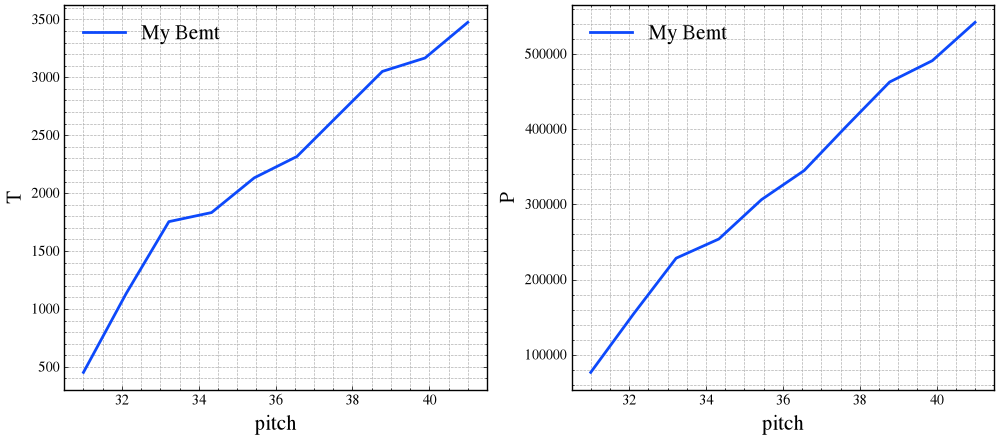

In [29]:
T=ca.vcat([i["T"] for i in aero_list])
P=ca.vcat([i["P"] for i in aero_list])

import matplotlib.pyplot as plt 
import scienceplots
with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(12, 5))
        ax = fig.add_subplot(121)
        ax.plot(np.linspace(31.0,41.0,10), T, label="My Bemt")

        ax.set_xlabel("pitch")
        ax.set_ylabel("T")
        ax.legend(fontsize=15)
        # ax.grid(True,"both",linestyle="-")

        ax = fig.add_subplot(122)
        ax.plot(np.linspace(31.0,41.0,10), P, label="My Bemt")
        ax.set_xlabel("pitch")
        ax.set_ylabel("P")
        ax.legend(fontsize=15)
 
        plt.show()